# Data Cleaning & EDA

In [28]:
!pip install gdown # installs python package gdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gdown

url = f'https://drive.google.com/uc?id=1oD-nvRJui1X8rB4UcBFI65WAAIWd4LFz'
output = 'Austin_Weather_99_23.csv'
gdown.download(url, output, quiet=False)

file_path = output

Downloading...
From: https://drive.google.com/uc?id=1oD-nvRJui1X8rB4UcBFI65WAAIWd4LFz
To: /content/Austin_Weather_99_23.csv
100%|██████████| 525k/525k [00:00<00:00, 42.4MB/s]


Change 'file_path' based off of where the dataset is located in your gDrive. I recommend just making a copy of the dataset to your home gDrive (not in any folder) and naming it exactly 'Austin_Weather_99_23.csv'. If you wanna change the path feel free to do so and if it doesn't work just tell me and I can help fix it

In [29]:

data = pd.read_csv(file_path)
data.shape

orig_data = data.copy() # store original df to check with later

### Missing counts & other basic stuff

In [30]:
data.isnull().sum()  # missing counts for each column

,0
Date,0
TempHighF,0
TempLowF,0
TempAvgF,0
DewPointAvgF,4
HumidityAvgPercent,1
sealevelpressure,0
VisibilityAvgMiles,4
PrecipitationSumInches,204
Events,6318


In [31]:
data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92,1008.7,4.2,NaN,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,NaN,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39,1029.8,9.9,NaN,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,NaN,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,NaN,NaN


In [32]:
data.describe()

,TempHighF,TempLowF,TempAvgF,PrecipitationSumInches
count,10354.000000,10354.000000,10354.000000,10150.000000
mean,80.349189,59.701111,69.491733,0.094914
std,14.771837,14.523552,14.077261,0.360494
min,22.600000,8.200000,15.700000,0.000000
25%,71.000000,48.000000,59.200000,0.000000
50%,82.300000,62.850000,71.900000,0.000000
75%,92.000000,72.900000,81.400000,0.006000
max,110.400000,84.500000,95.100000,7.489000


In [33]:
# all numeric columns
numeric_columns = [
    'PrecipitationSumInches',
    'DewPointAvgF',
    'TempHighF',
    'TempAvgF',
    'TempLowF',
    'HumidityAvgPercent',
    'sealevelpressure',
    'VisibilityAvgMiles'
]

for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce') # iterates thru, converts all to a numeric data type so no cleaning issues
    median_data = data[col].median() # get median
    data[col] = data[col].fillna(median_data) # fill empty values with median
    print("Column" , col, ":", median_data)

data.head()



Column PrecipitationSumInches : 0.0
Column DewPointAvgF : 60.6
Column TempHighF : 82.3
Column TempAvgF : 71.9
Column TempLowF : 62.849999999999994
Column HumidityAvgPercent : 66.5
Column sealevelpressure : 1015.6
Column VisibilityAvgMiles : 9.8


,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,NaN
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,NaN
2,1/3/1999,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,NaN
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,NaN
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,NaN


The above code just fills in all null values with the median. It's extremely modular so whenever we use different datasets we can just change the 'numeric_columns' table and put whatever columns we want there.

Note that we didn't touch the 'Events' column as there's only a qualitative values there. For the sake of cleaning let's assume that an empty value means 'sunny'. The code to fill in this special case is below

In [34]:
data['Events'] = data['Events'].fillna("sunny") # fills empty event with sunny. can change this later

data.head()

,Date,TempHighF,TempLowF,TempAvgF,DewPointAvgF,HumidityAvgPercent,sealevelpressure,VisibilityAvgMiles,PrecipitationSumInches,Events
0,1/1/1999,73.9,51.8,60.5,57.9,92.0,1008.7,4.2,0.0,sunny
1,1/2/1999,64.3,37.2,48.2,30.4,52.1,1016.6,9.7,0.0,sunny
2,1/3/1999,39.7,30.3,35.6,12.1,39.0,1029.8,9.9,0.0,sunny
3,1/4/1999,42.8,28.0,34.2,13.9,43.7,1034.9,9.9,0.0,sunny
4,1/5/1999,55.5,21.4,39.7,31.4,72.6,1026.7,9.9,0.0,sunny


Now, all data is fully cleaned, let's just confirm

In [35]:
data.isnull().sum()

,0
Date,0
TempHighF,0
TempLowF,0
TempAvgF,0
DewPointAvgF,0
HumidityAvgPercent,0
sealevelpressure,0
VisibilityAvgMiles,0
PrecipitationSumInches,0
Events,0


There are no null values as shown above so we can make some plots now and compare to orig_data.

Date                             0
TempHighF                        0
TempLowF                         0
TempAvgF                         0
DewPointAvgF                     0
HumidityAvgPercent               0
sealevelpressure                 0
VisibilityAvgMiles               0
PrecipitationSumInches           0
Events                           0
TempHighF_7Day                   6
TempHighF_30Day                 29
TempLowF_7Day                    6
TempLowF_30Day                  29
TempAvgF_7Day                    6
TempAvgF_30Day                  29
DewPointAvgF_7Day                6
DewPointAvgF_30Day              29
HumidityAvgPercent_7Day          6
HumidityAvgPercent_30Day        29
sealevelpressure_7Day            6
sealevelpressure_30Day          29
VisibilityAvgMiles_7Day          6
VisibilityAvgMiles_30Day        29
PrecipitationSumInches_7Day      6
PrecipitationSumInches_30Day    29
dtype: int64

First few rows:
        Date  TempHighF  TempLowF  TempAvgF  DewPointAvgF  H

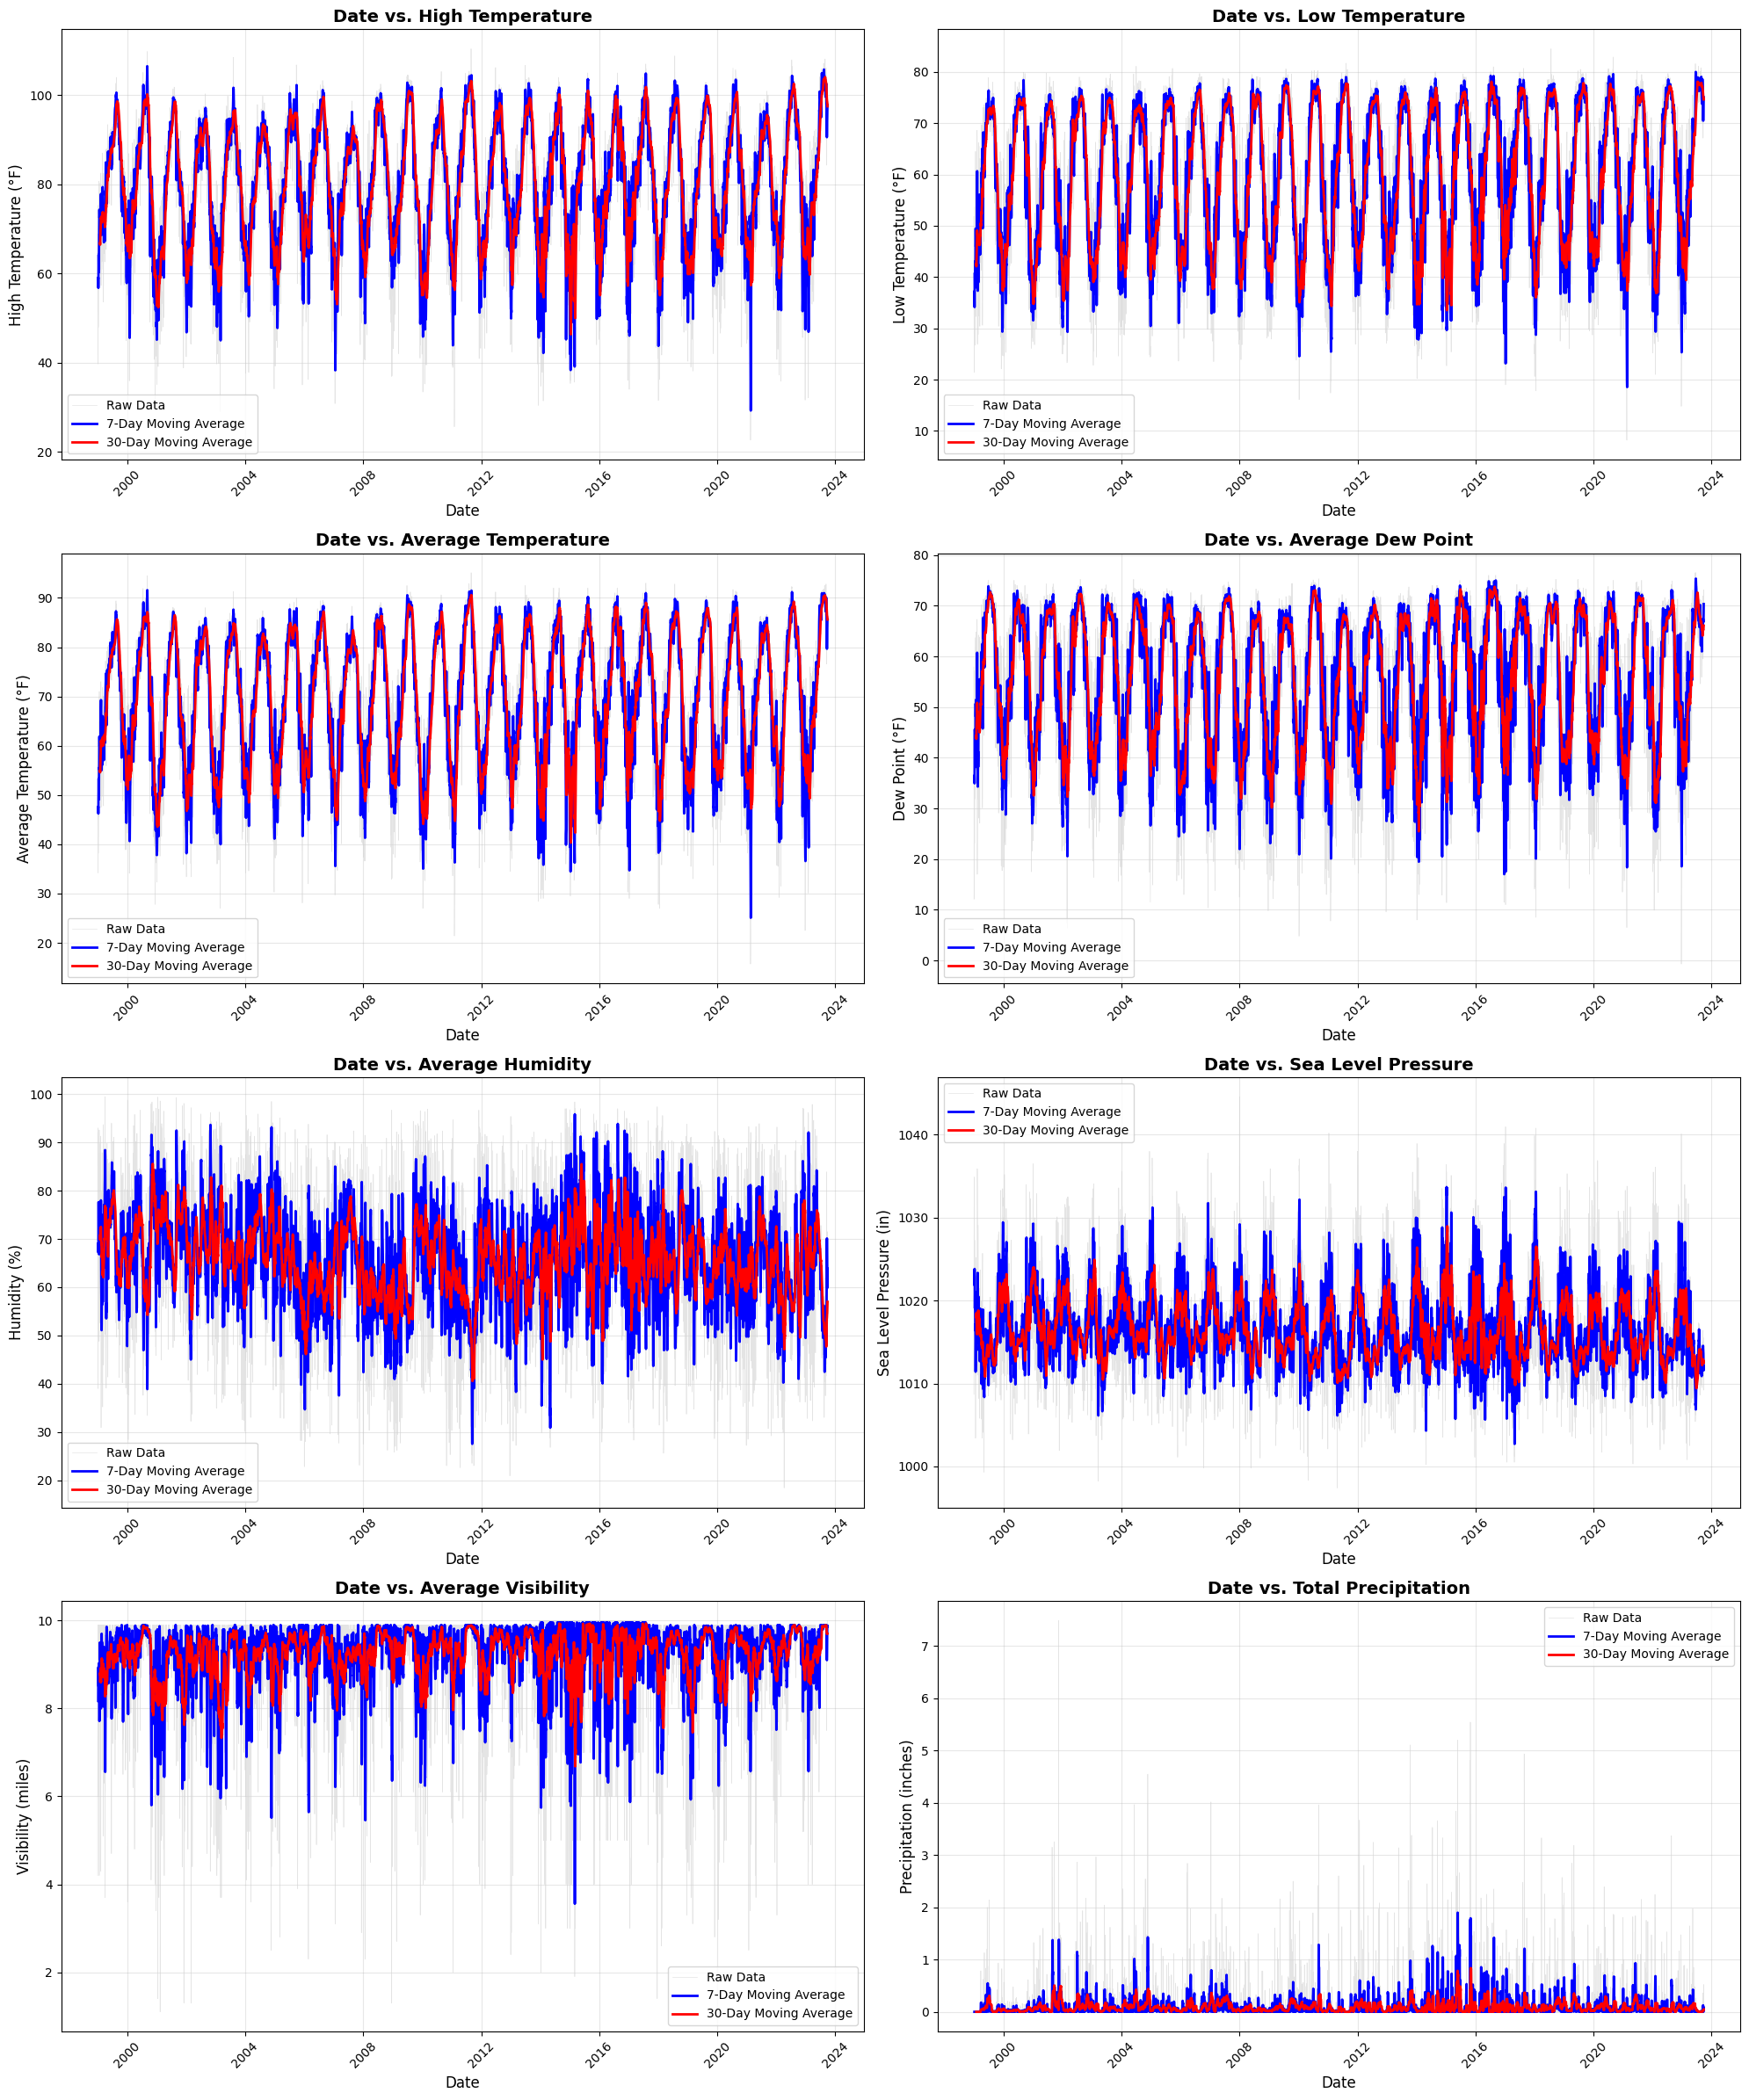

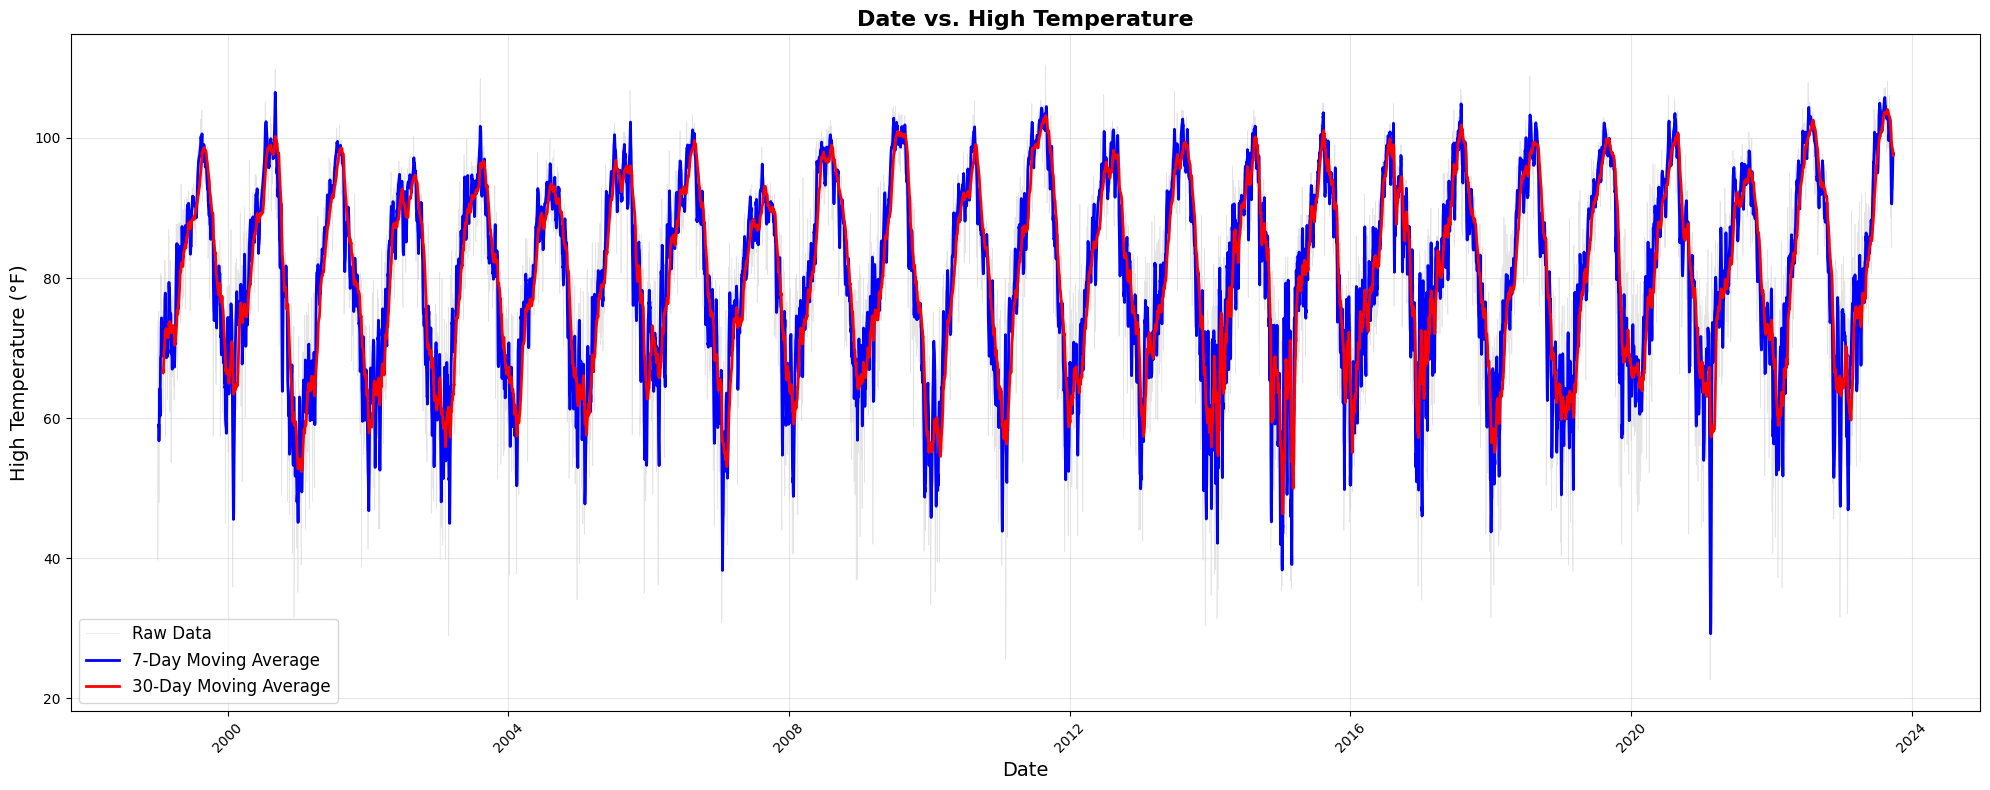

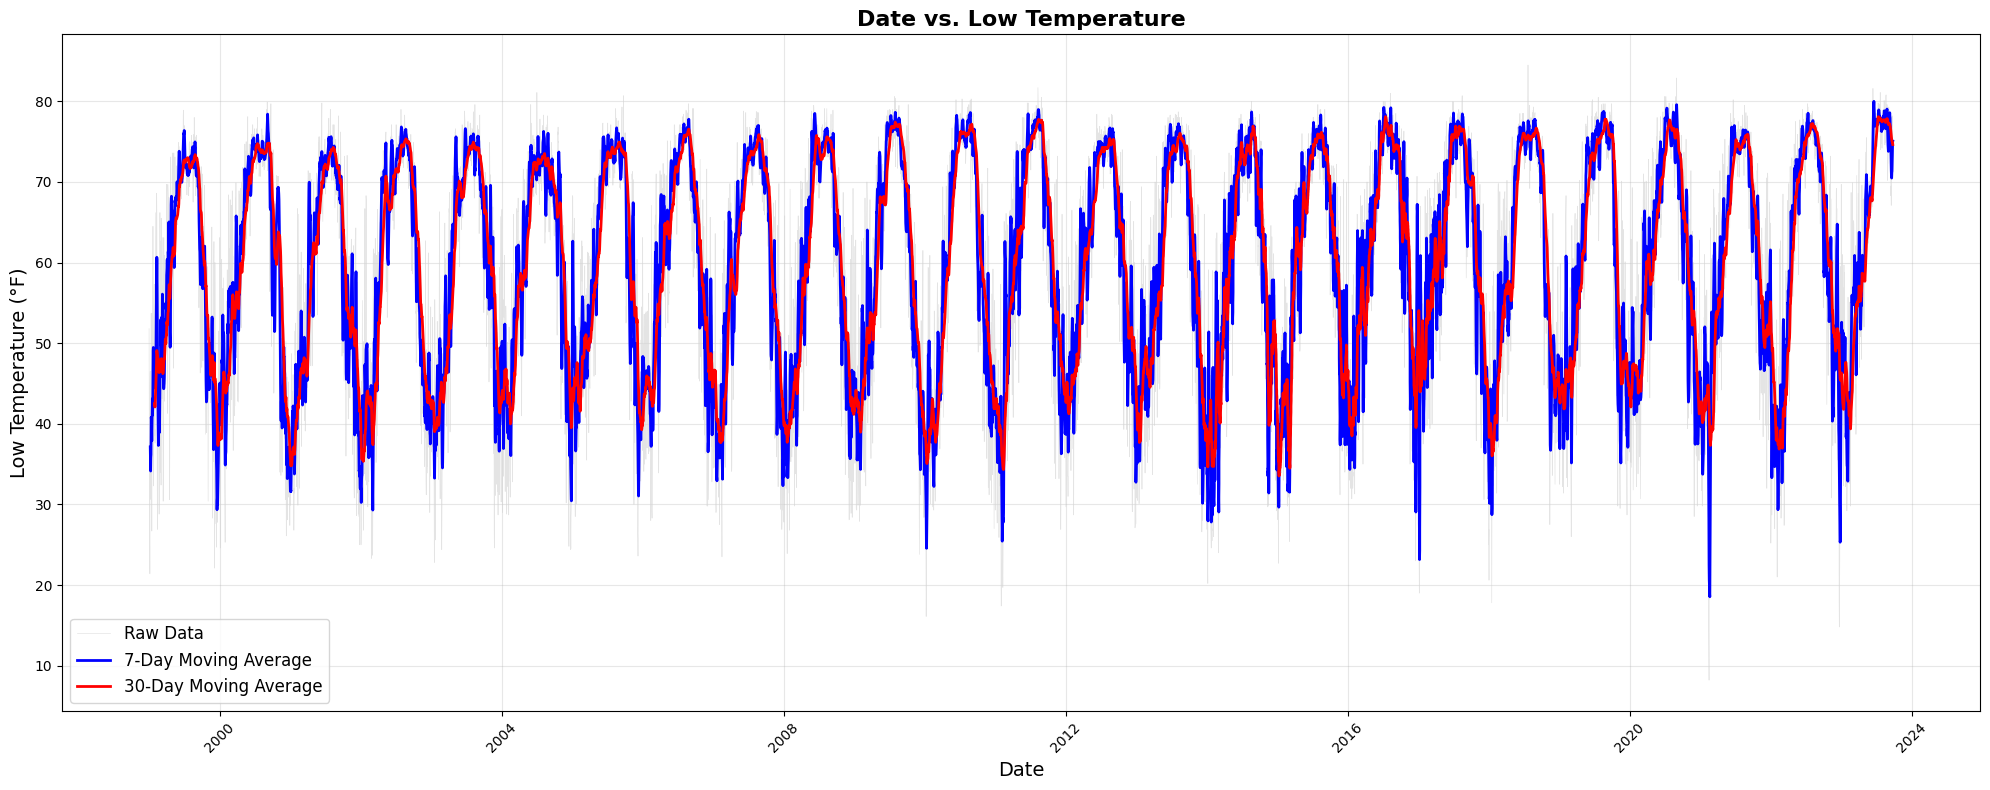

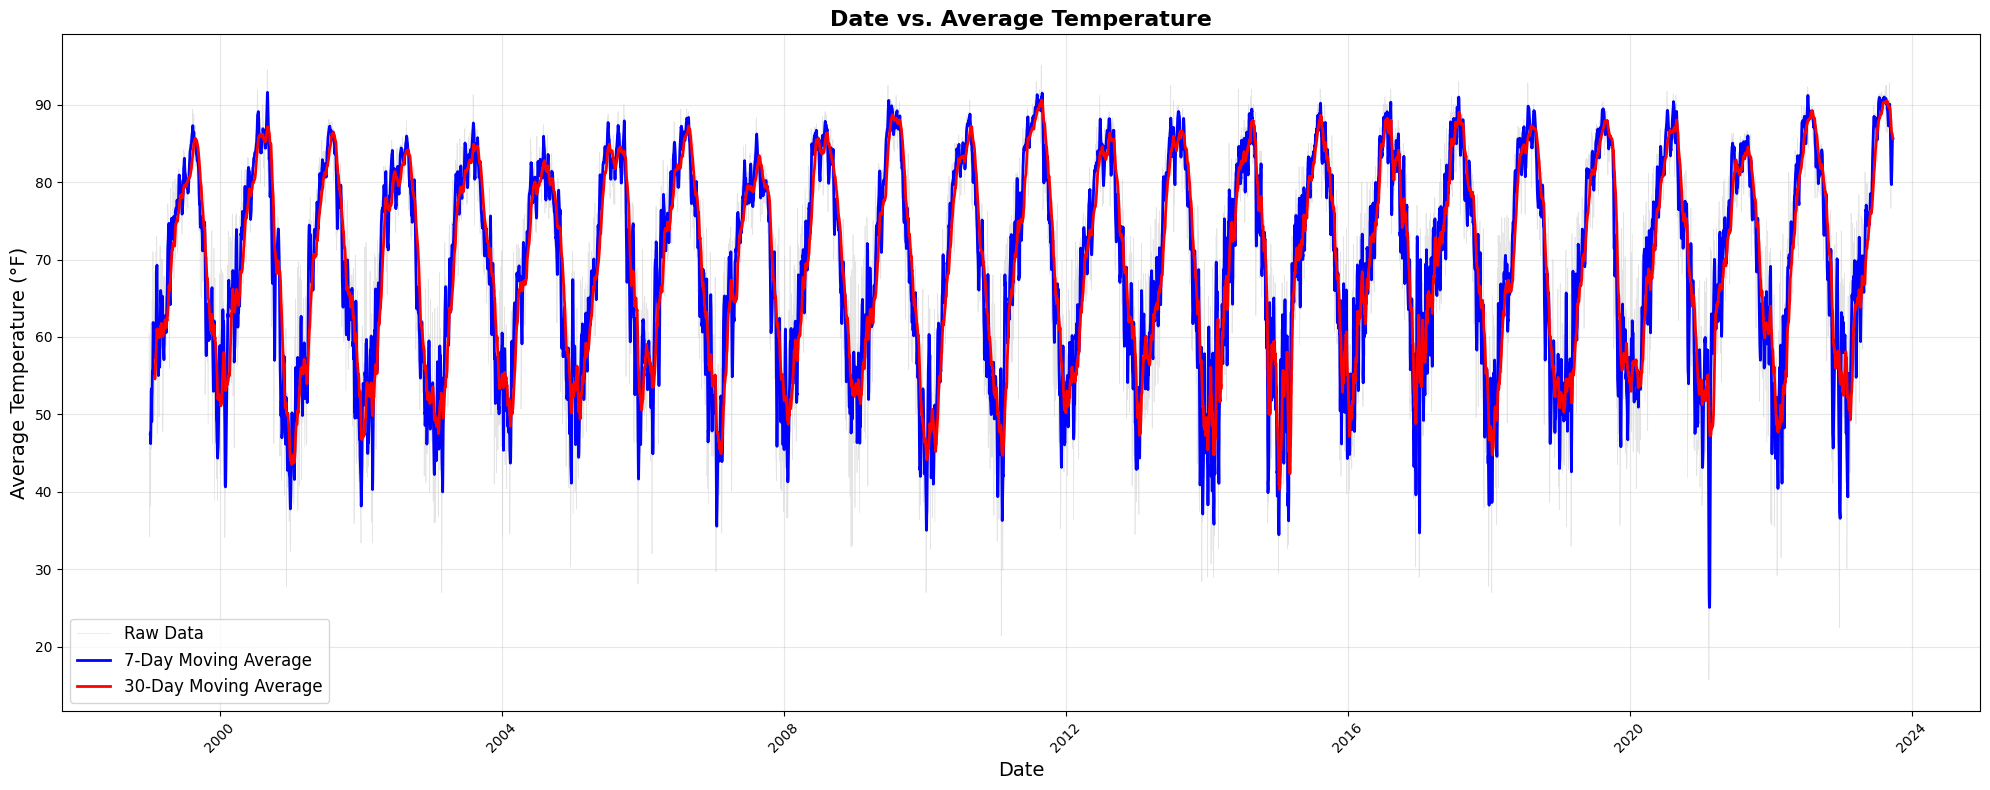

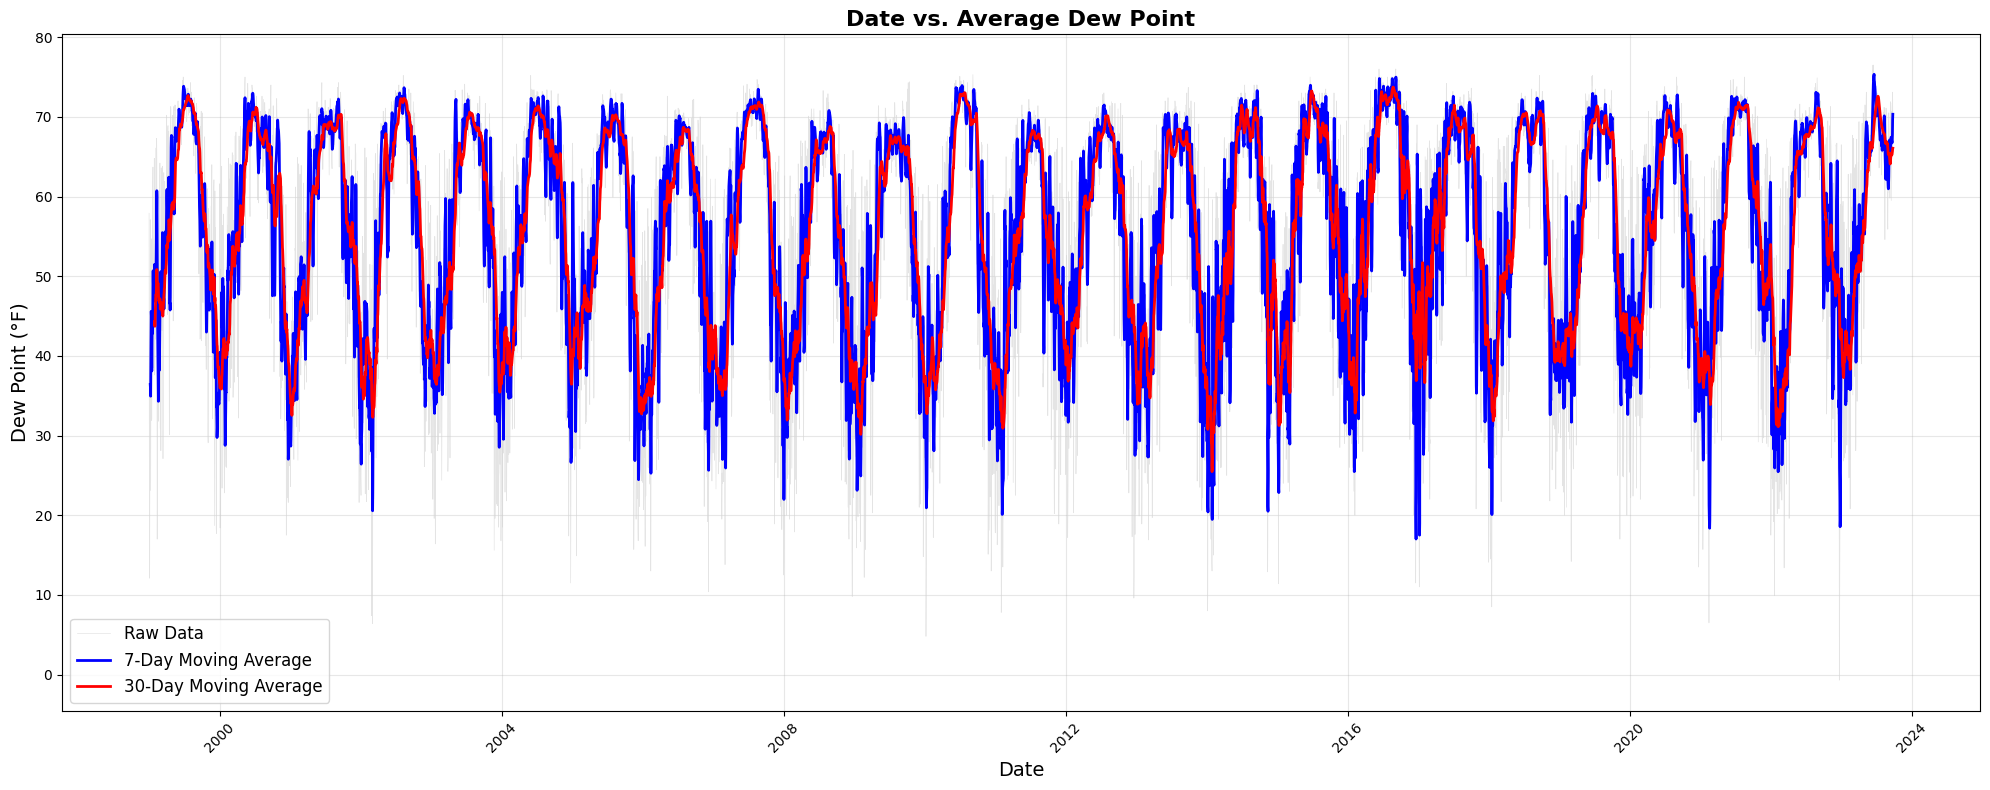

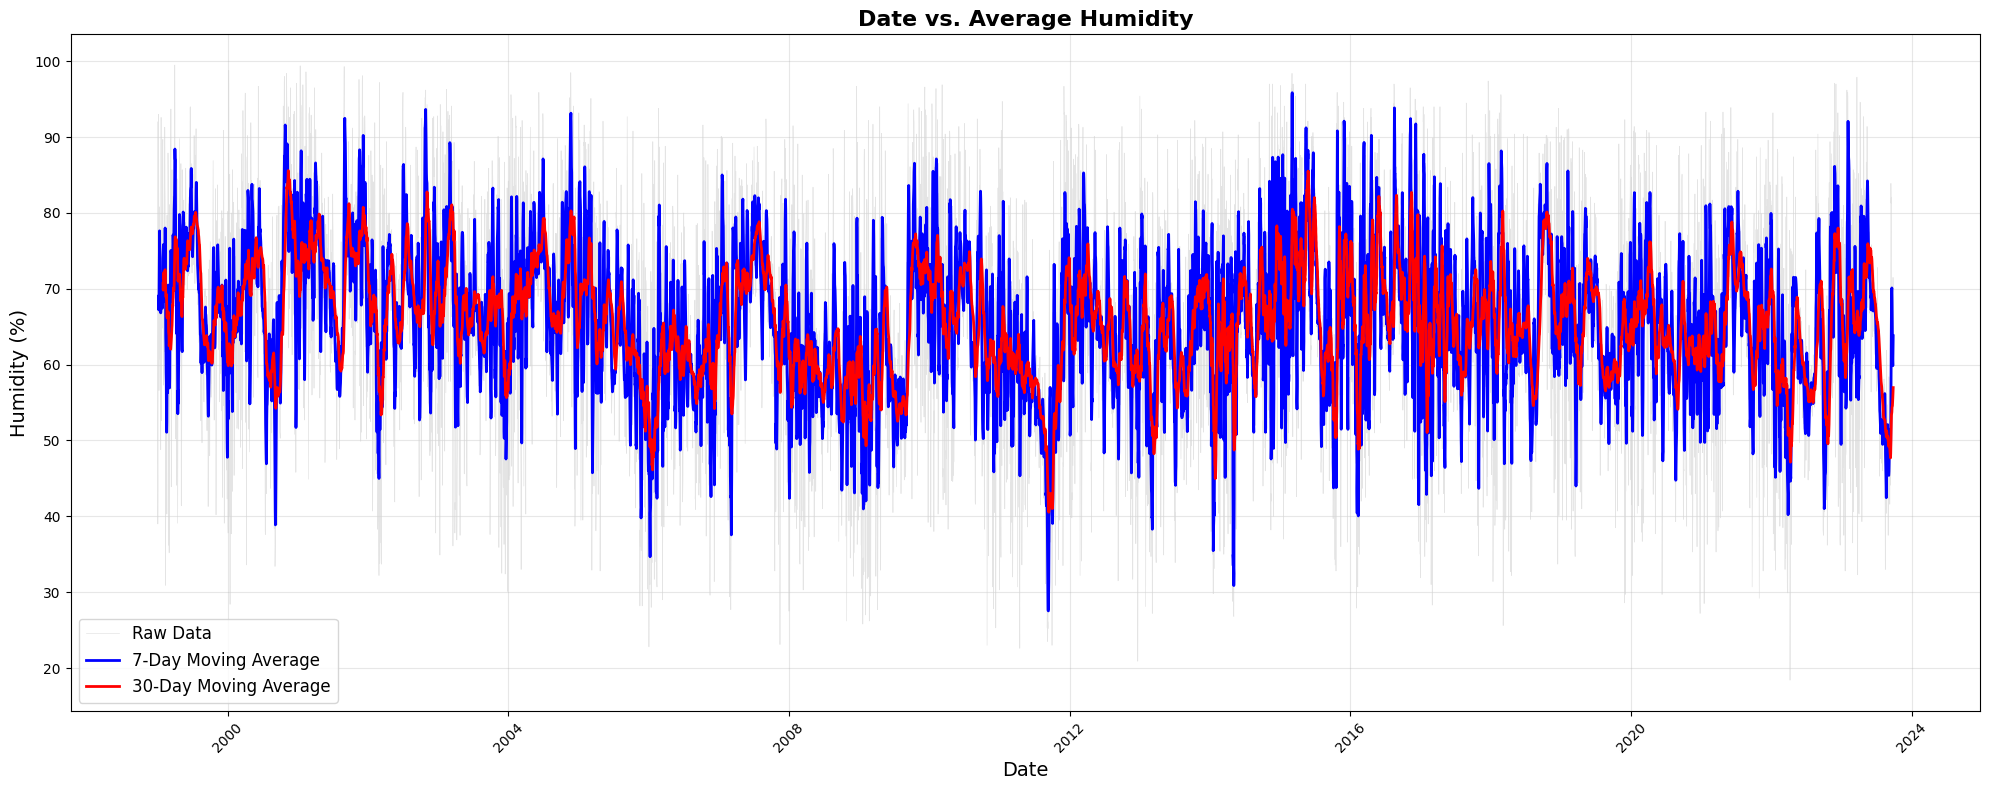

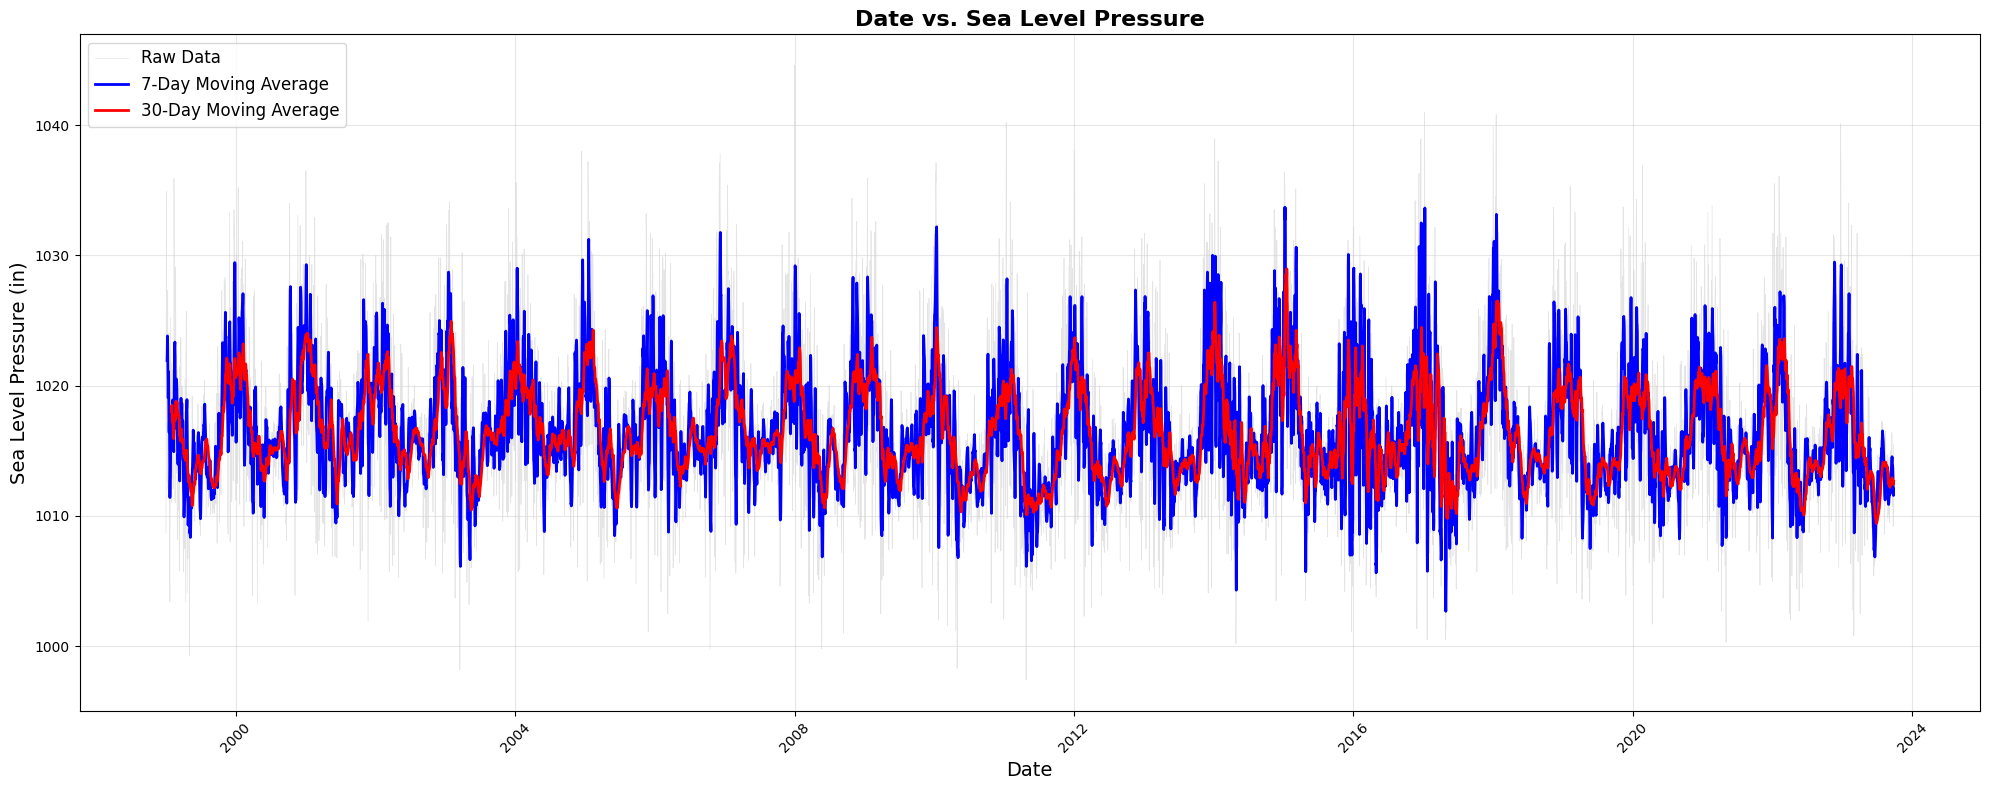

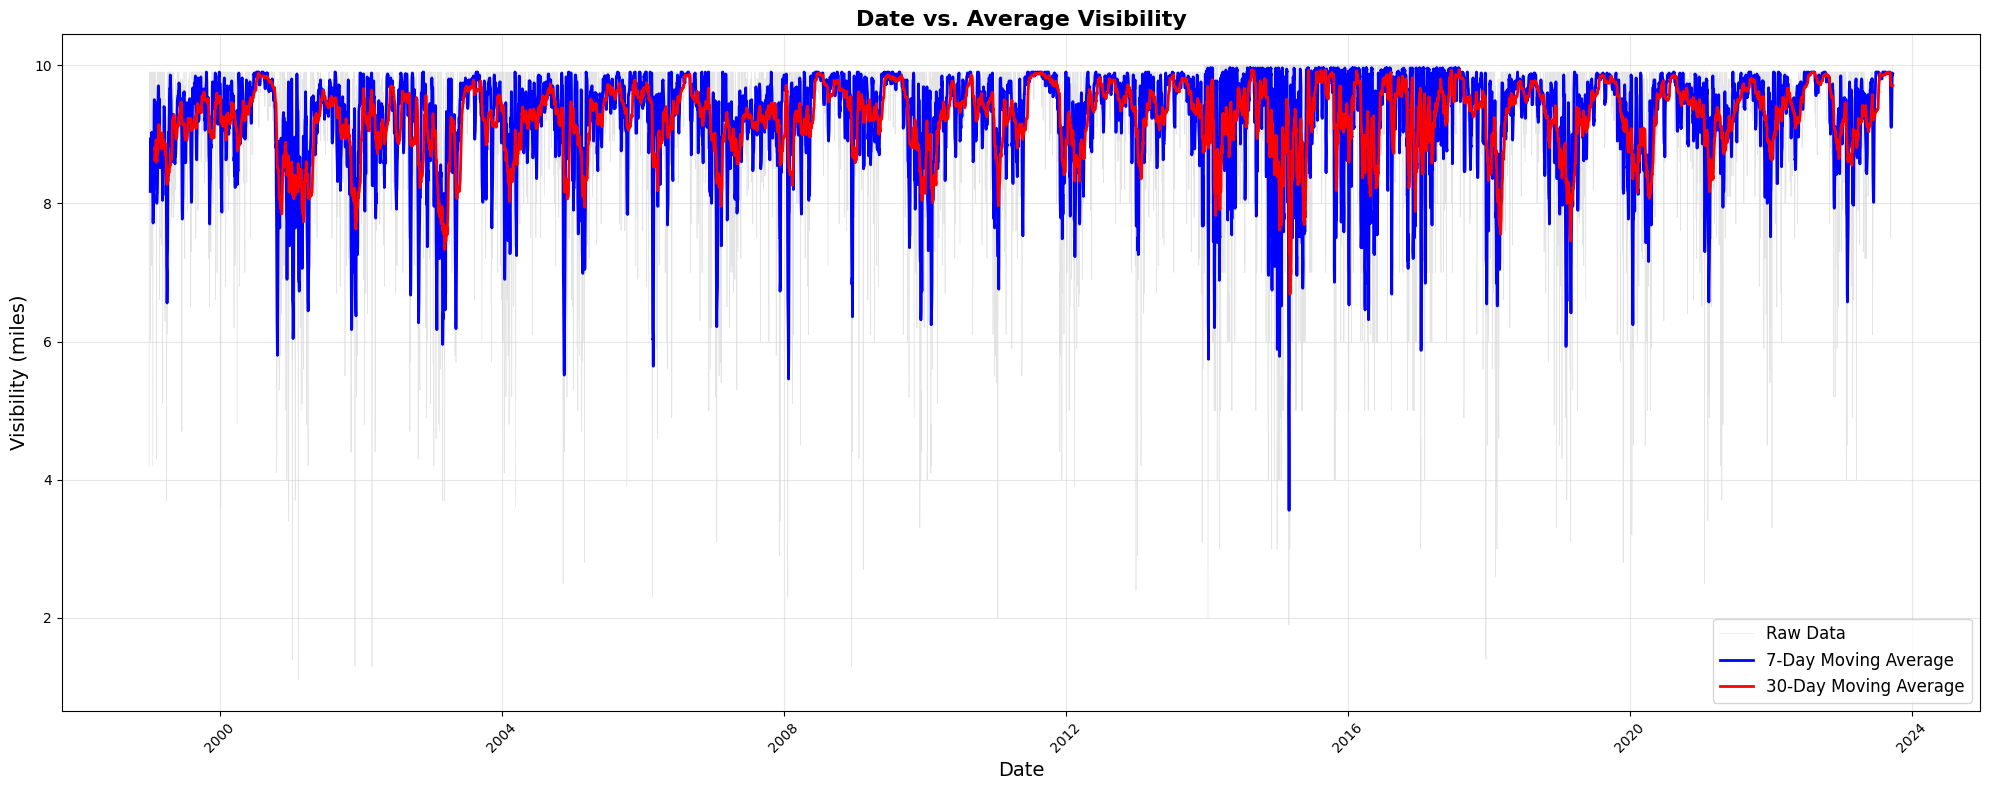

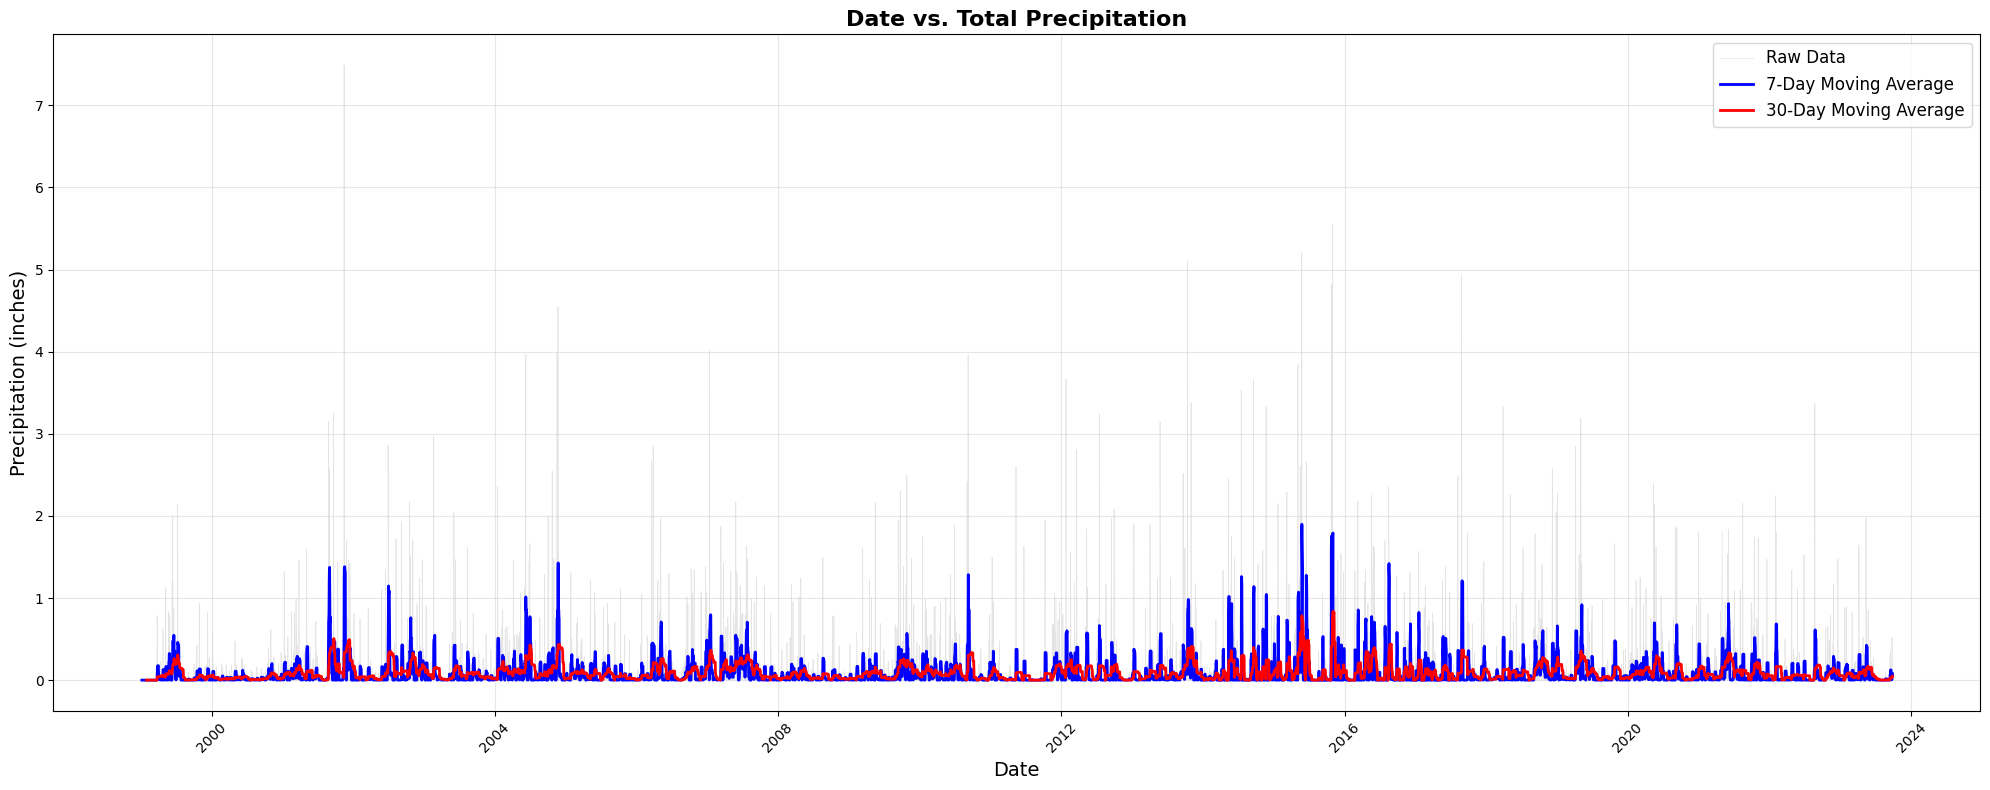

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Calculate 7-day and 30-day rolling averages for all variables
variables = ['TempHighF', 'TempLowF', 'TempAvgF', 'DewPointAvgF',
             'HumidityAvgPercent', 'sealevelpressure',
             'VisibilityAvgMiles', 'PrecipitationSumInches']

for var in variables:
    data[f'{var}_7Day'] = data[var].rolling(window=7).mean()
    data[f'{var}_30Day'] = data[var].rolling(window=30).mean()

# Check for null values
print(data.isnull().sum())
print("\nFirst few rows:")
print(data.head())

# Create individual plots for each variable
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()

# Plot settings for each variable
plot_configs = [
    ('TempHighF', 'High Temperature (°F)', 'Date vs. High Temperature'),
    ('TempLowF', 'Low Temperature (°F)', 'Date vs. Low Temperature'),
    ('TempAvgF', 'Average Temperature (°F)', 'Date vs. Average Temperature'),
    ('DewPointAvgF', 'Dew Point (°F)', 'Date vs. Average Dew Point'),
    ('HumidityAvgPercent', 'Humidity (%)', 'Date vs. Average Humidity'),
    ('sealevelpressure', 'Sea Level Pressure (in)', 'Date vs. Sea Level Pressure'),
    ('VisibilityAvgMiles', 'Visibility (miles)', 'Date vs. Average Visibility'),
    ('PrecipitationSumInches', 'Precipitation (inches)', 'Date vs. Total Precipitation')
]

for idx, (var, ylabel, title) in enumerate(plot_configs):
    ax = axes[idx]

    # Plot raw data with thin line
    ax.plot(data['Date'], data[var], label='Raw Data',
            linewidth=0.5, alpha=0.6, color='lightgray')

    # Plot 7-day rolling average
    ax.plot(data['Date'], data[f'{var}_7Day'], label='7-Day Moving Average',
            linewidth=2, color='blue')

    # Plot 30-day rolling average
    ax.plot(data['Date'], data[f'{var}_30Day'], label='30-Day Moving Average',
            linewidth=2, color='red')

    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Optional: Create individual full-size plots for each variable
for var, ylabel, title in plot_configs:
    plt.figure(figsize=(20, 8))

    plt.plot(data['Date'], data[var], label='Raw Data',
             linewidth=0.5, alpha=0.6, color='lightgray')
    plt.plot(data['Date'], data[f'{var}_7Day'], label='7-Day Moving Average',
             linewidth=2, color='blue')
    plt.plot(data['Date'], data[f'{var}_30Day'], label='30-Day Moving Average',
             linewidth=2, color='red')

    plt.xlabel('Date', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Regression Modeling


LINEAR REGRESSION ANALYSIS BY SEASON

Winter:
  Equation: TempAvgF = 0.000192 * DaysSince1999 + 52.42
  R-squared: 0.0023
  P-value: 1.564135e-02
  Temperature change per year: 0.0700°F/year

Spring:
  Equation: TempAvgF = 0.000129 * DaysSince1999 + 68.80
  R-squared: 0.0014
  P-value: 5.532534e-02
  Temperature change per year: 0.0472°F/year

Summer:
  Equation: TempAvgF = 0.000408 * DaysSince1999 + 82.37
  R-squared: 0.0691
  P-value: 6.661283e-43
  Temperature change per year: 0.1490°F/year

Fall:
  Equation: TempAvgF = 0.000384 * DaysSince1999 + 68.74
  R-squared: 0.0075
  P-value: 1.560711e-05
  Temperature change per year: 0.1402°F/year


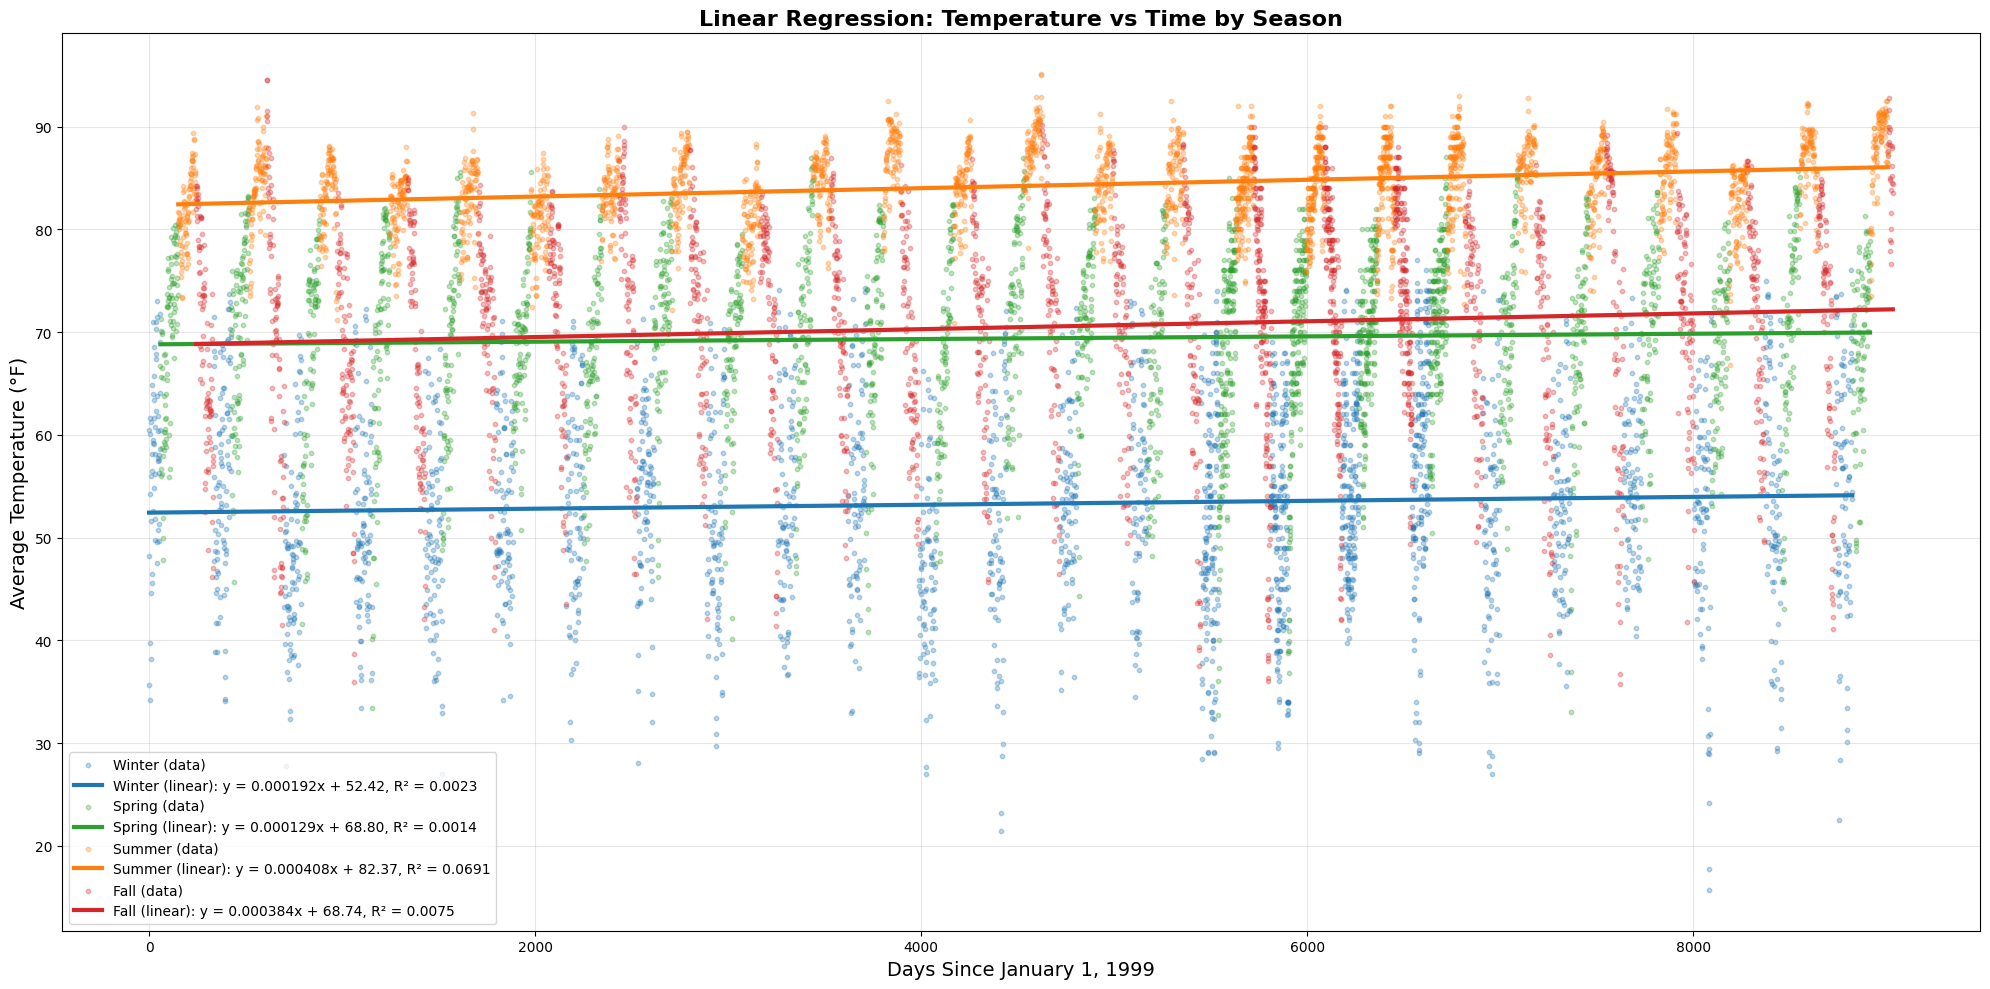


LOGARITHMIC REGRESSION ANALYSIS BY SEASON

Winter:
  Equation: TempAvgF = -0.0423 * ln(DaysSince1999 + 1) + 53.66
  R-squared: 0.0000
  P-value: 8.150491e-01

Spring:
  Equation: TempAvgF = 0.2645 * ln(DaysSince1999 + 1) + 67.25
  R-squared: 0.0009
  P-value: 1.249802e-01

Summer:
  Equation: TempAvgF = 1.0848 * ln(DaysSince1999 + 1) + 75.41
  R-squared: 0.0604
  P-value: 1.412255e-37

Fall:
  Equation: TempAvgF = 1.0976 * ln(DaysSince1999 + 1) + 61.53
  R-squared: 0.0069
  P-value: 3.439428e-05


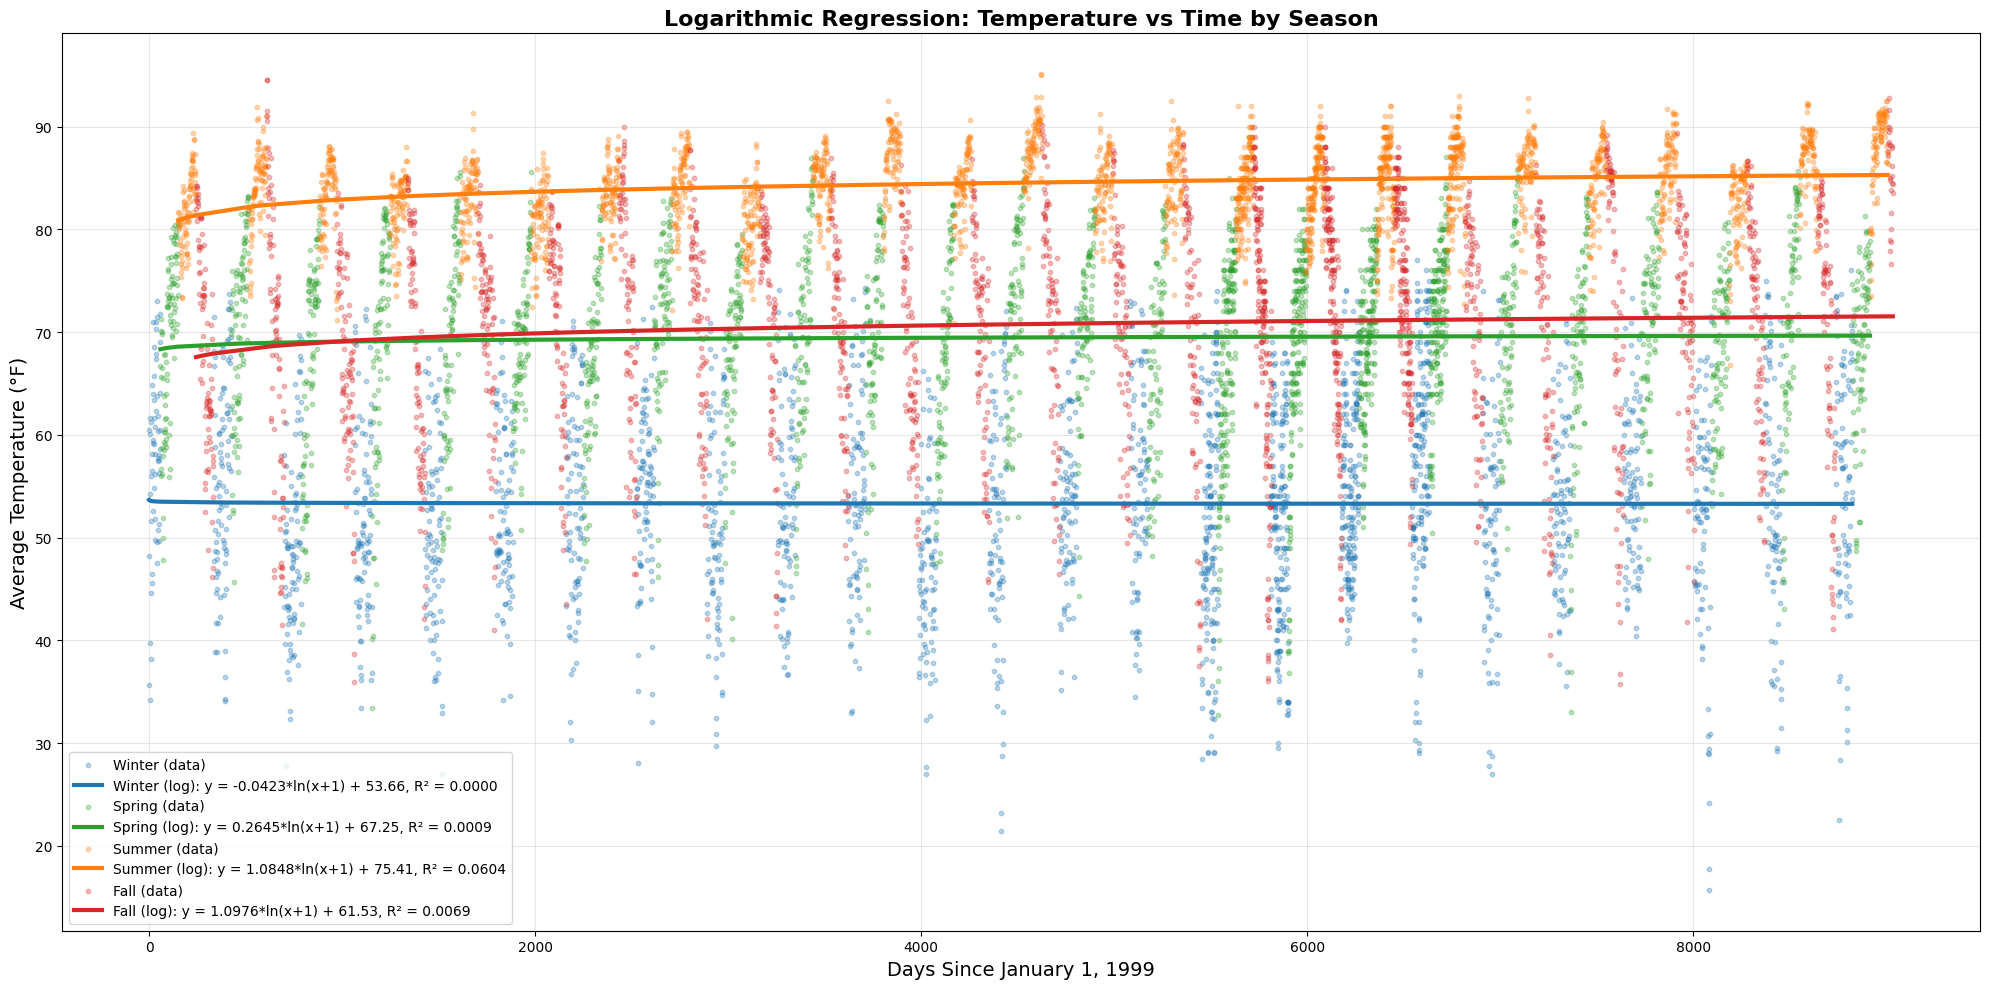


MODEL COMPARISON: LINEAR vs LOGARITHMIC

 Season  Linear R²  Logarithmic R² Better Model
Winter   0.002277        0.000021       Linear
Spring   0.001377        0.000883       Linear
Summer   0.069061        0.060402       Linear
  Fall   0.007495        0.006893       Linear


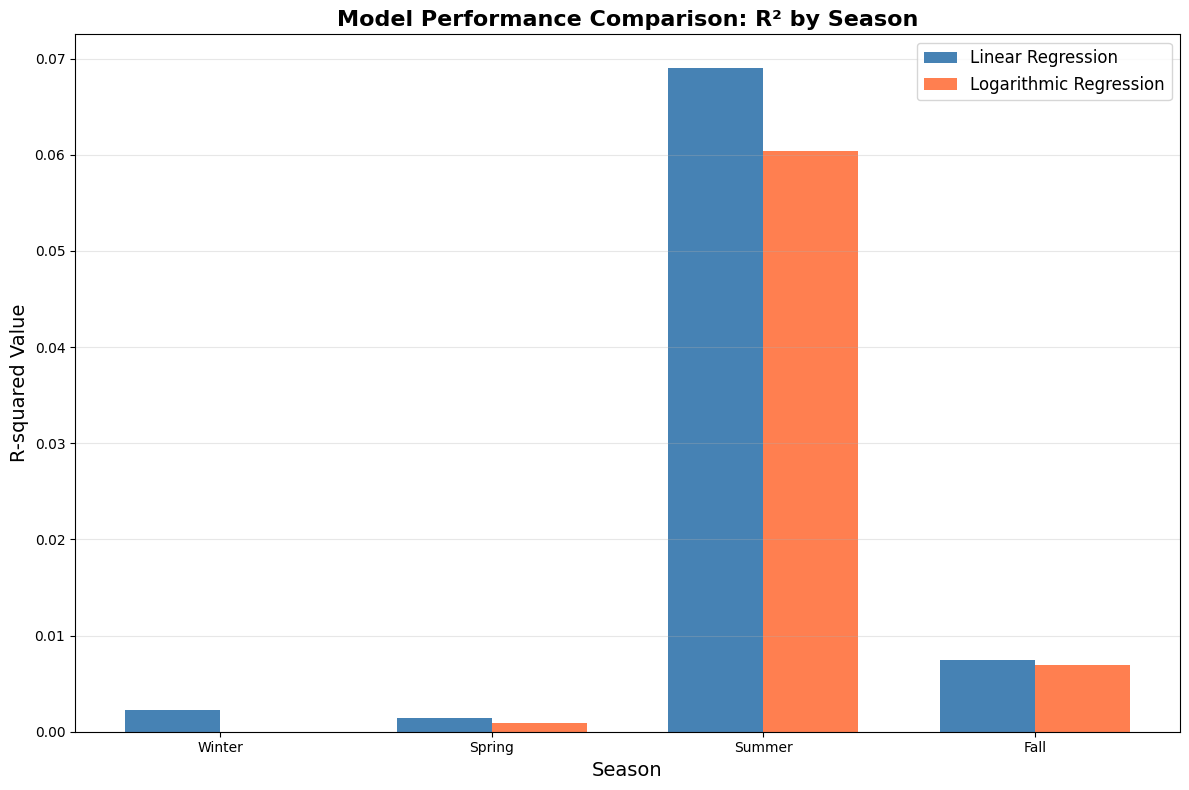


SUMMARY STATISTICS BY SEASON

         Count   Mean  Std Dev   Min   Max
Season                                   
Fall     2483  70.55    10.94  35.7  94.5
Spring   2668  69.41     8.75  32.7  87.0
Summer   2637  84.32     3.91  66.8  95.1
Winter   2566  53.32     9.98  15.7  77.0


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

# Ensure Date is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Create a "days since 1999" column for regression
start_date = pd.Timestamp('1999-01-01')
data['DaysSince1999'] = (data['Date'] - start_date).dt.days

# Define seasons based on month
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

data['Season'] = data['Date'].dt.month.apply(get_season)

# Remove any rows with missing temperature data
data_clean = data.dropna(subset=['TempAvgF', 'DaysSince1999'])

# Define colors for each season
season_colors = {
    'Winter': '#1f77b4',  # Blue
    'Spring': '#2ca02c',  # Green
    'Summer': '#ff7f0e',  # Orange
    'Fall': '#d62728'     # Red
}

# ============================================================================
# LINEAR REGRESSION BY SEASON
# ============================================================================
print("="*80)
print("LINEAR REGRESSION ANALYSIS BY SEASON")
print("="*80)

plt.figure(figsize=(20, 10))

# Store regression results
linear_results = {}

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_data = data_clean[data_clean['Season'] == season]

    x = season_data['DaysSince1999'].values
    y = season_data['TempAvgF'].values

    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Calculate predictions
    y_pred = slope * x + intercept
    r_squared = r2_score(y, y_pred)

    # Store results
    linear_results[season] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value
    }

    # Plot scatter and regression line
    plt.scatter(x, y, alpha=0.3, s=10, color=season_colors[season], label=f'{season} (data)')
    plt.plot(x, y_pred, linewidth=3, color=season_colors[season],
             label=f'{season} (linear): y = {slope:.6f}x + {intercept:.2f}, R² = {r_squared:.4f}')

    # Print results
    print(f"\n{season}:")
    print(f"  Equation: TempAvgF = {slope:.6f} * DaysSince1999 + {intercept:.2f}")
    print(f"  R-squared: {r_squared:.4f}")
    print(f"  P-value: {p_value:.6e}")
    print(f"  Temperature change per year: {slope * 365.25:.4f}°F/year")

plt.xlabel('Days Since January 1, 1999', fontsize=14)
plt.ylabel('Average Temperature (°F)', fontsize=14)
plt.title('Linear Regression: Temperature vs Time by Season', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('linear_regression_by_season.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# LOGARITHMIC REGRESSION BY SEASON
# ============================================================================
print("\n" + "="*80)
print("LOGARITHMIC REGRESSION ANALYSIS BY SEASON")
print("="*80)

plt.figure(figsize=(20, 10))

# Store regression results
log_results = {}

for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_data = data_clean[data_clean['Season'] == season]

    x = season_data['DaysSince1999'].values
    y = season_data['TempAvgF'].values

    # Logarithmic regression: y = a * ln(x) + b
    # We need x > 0, so add 1 to avoid ln(0)
    x_log = np.log(x + 1)

    # Perform linear regression on log-transformed x
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y)

    # Calculate predictions
    y_pred = slope * np.log(x + 1) + intercept
    r_squared = r2_score(y, y_pred)

    # Store results
    log_results[season] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value
    }

    # Plot scatter and regression line
    plt.scatter(x, y, alpha=0.3, s=10, color=season_colors[season], label=f'{season} (data)')
    plt.plot(x, y_pred, linewidth=3, color=season_colors[season],
             label=f'{season} (log): y = {slope:.4f}*ln(x+1) + {intercept:.2f}, R² = {r_squared:.4f}')

    # Print results
    print(f"\n{season}:")
    print(f"  Equation: TempAvgF = {slope:.4f} * ln(DaysSince1999 + 1) + {intercept:.2f}")
    print(f"  R-squared: {r_squared:.4f}")
    print(f"  P-value: {p_value:.6e}")

plt.xlabel('Days Since January 1, 1999', fontsize=14)
plt.ylabel('Average Temperature (°F)', fontsize=14)
plt.title('Logarithmic Regression: Temperature vs Time by Season', fontsize=16, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logarithmic_regression_by_season.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# COMPARISON: LINEAR VS LOGARITHMIC R-SQUARED
# ============================================================================
print("\n" + "="*80)
print("MODEL COMPARISON: LINEAR vs LOGARITHMIC")
print("="*80)

comparison_data = []
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    comparison_data.append({
        'Season': season,
        'Linear R²': linear_results[season]['r_squared'],
        'Logarithmic R²': log_results[season]['r_squared'],
        'Better Model': 'Linear' if linear_results[season]['r_squared'] > log_results[season]['r_squared'] else 'Logarithmic'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Bar chart comparing R-squared values
fig, ax = plt.subplots(figsize=(12, 8))

x_pos = np.arange(len(['Winter', 'Spring', 'Summer', 'Fall']))
width = 0.35

linear_r2 = [linear_results[s]['r_squared'] for s in ['Winter', 'Spring', 'Summer', 'Fall']]
log_r2 = [log_results[s]['r_squared'] for s in ['Winter', 'Spring', 'Summer', 'Fall']]

ax.bar(x_pos - width/2, linear_r2, width, label='Linear Regression', color='steelblue')
ax.bar(x_pos + width/2, log_r2, width, label='Logarithmic Regression', color='coral')

ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('R-squared Value', fontsize=14)
ax.set_title('Model Performance Comparison: R² by Season', fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Winter', 'Spring', 'Summer', 'Fall'])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison_r_squared.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS BY SEASON")
print("="*80)

summary_stats = data_clean.groupby('Season')['TempAvgF'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2)

print("\n", summary_stats)

POLYNOMIAL REGRESSION (DEGREE 2) BY SEASON

Winter:
  Equation: TempAvgF = 0.000000086x^2 + -0.000562x + 53.54
  R-squared: 0.0048

Spring:
  Equation: TempAvgF = 0.000000026x^2 + -0.000098x + 69.14
  R-squared: 0.0017

Summer:
  Equation: TempAvgF = -0.000000010x^2 + 0.000496x + 82.23
  R-squared: 0.0693

Fall:
  Equation: TempAvgF = -0.000000023x^2 + 0.000591x + 68.42
  R-squared: 0.0076


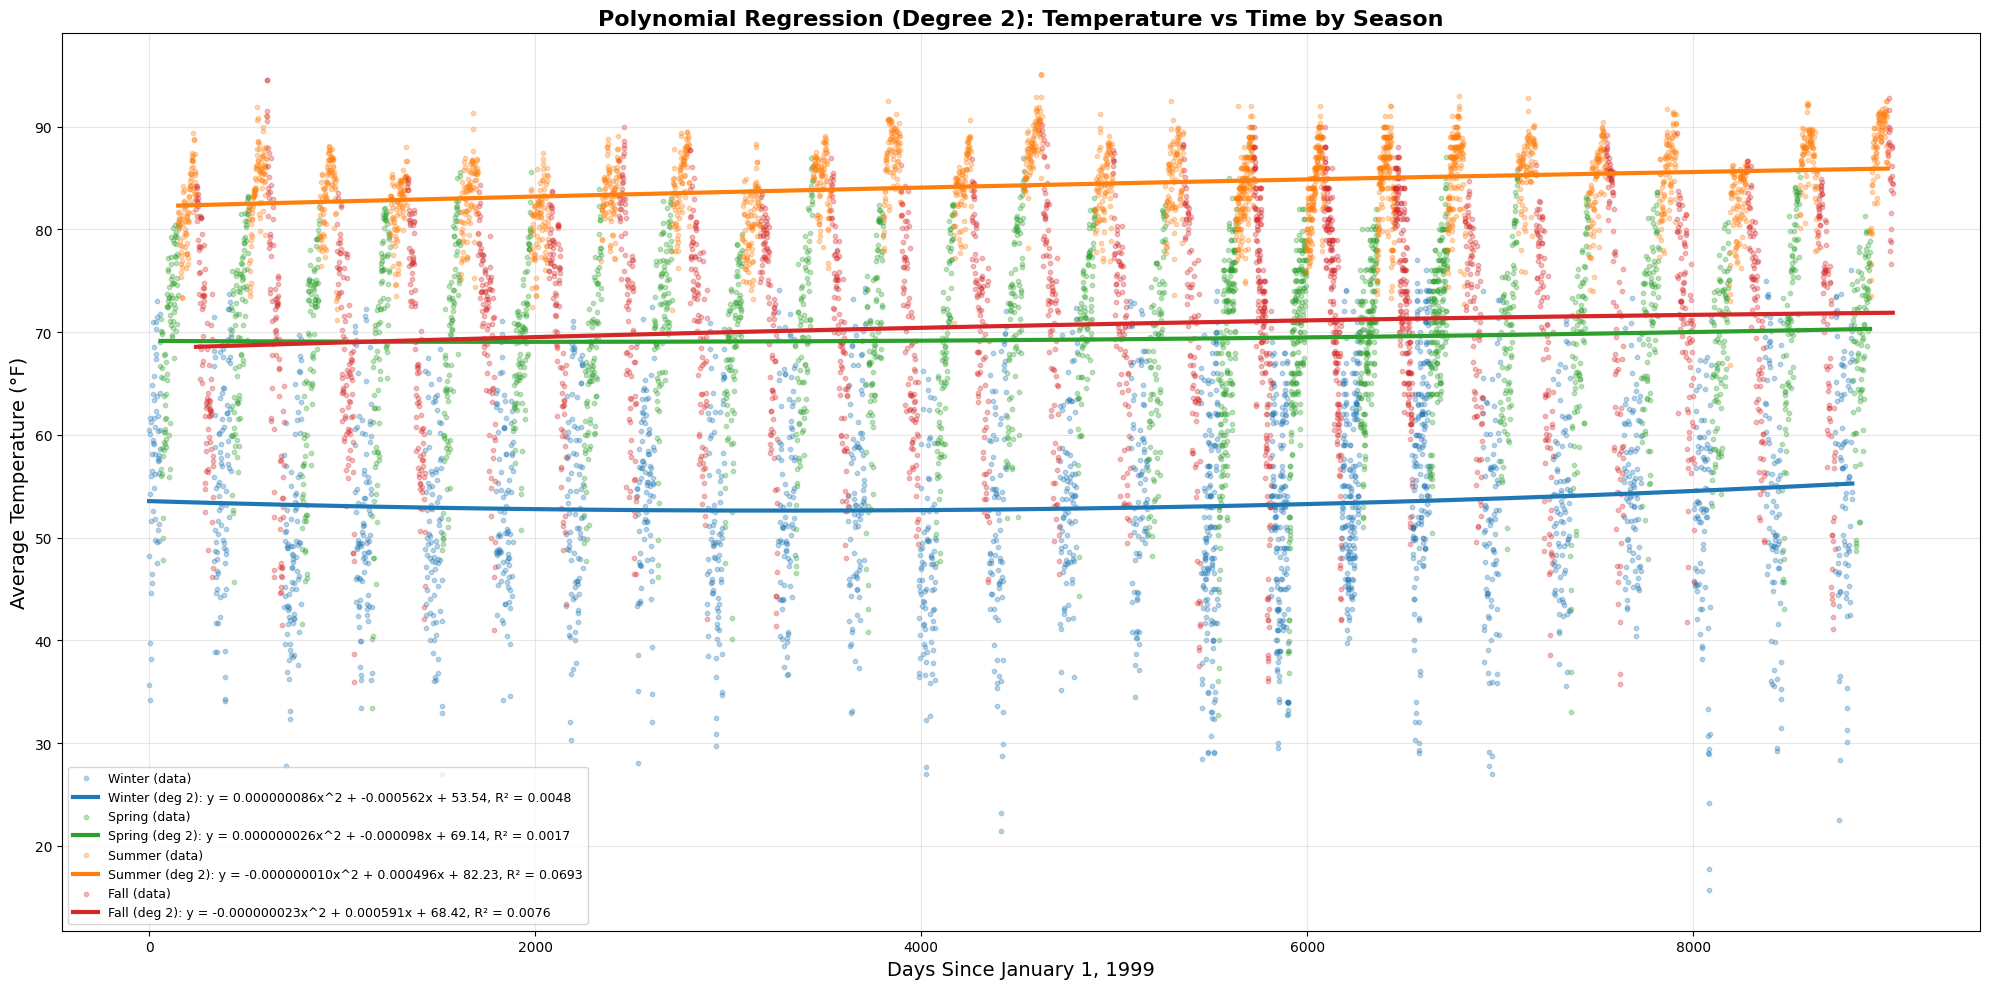

POLYNOMIAL REGRESSION (DEGREE 3) BY SEASON

Winter:
  Equation: TempAvgF = -0.000000000x^3 + 0.000000710x^2 + -0.002834x + 55.23
  R-squared: 0.0088

Spring:
  Equation: TempAvgF = 0.000000000x^3 + -0.000000006x^2 + 0.000017x + 69.05
  R-squared: 0.0017

Summer:
  Equation: TempAvgF = 0.000000000x^3 + -0.000000178x^2 + 0.001130x + 81.73
  R-squared: 0.0712

Fall:
  Equation: TempAvgF = 0.000000000x^3 + -0.000000311x^2 + 0.001677x + 67.52
  R-squared: 0.0083


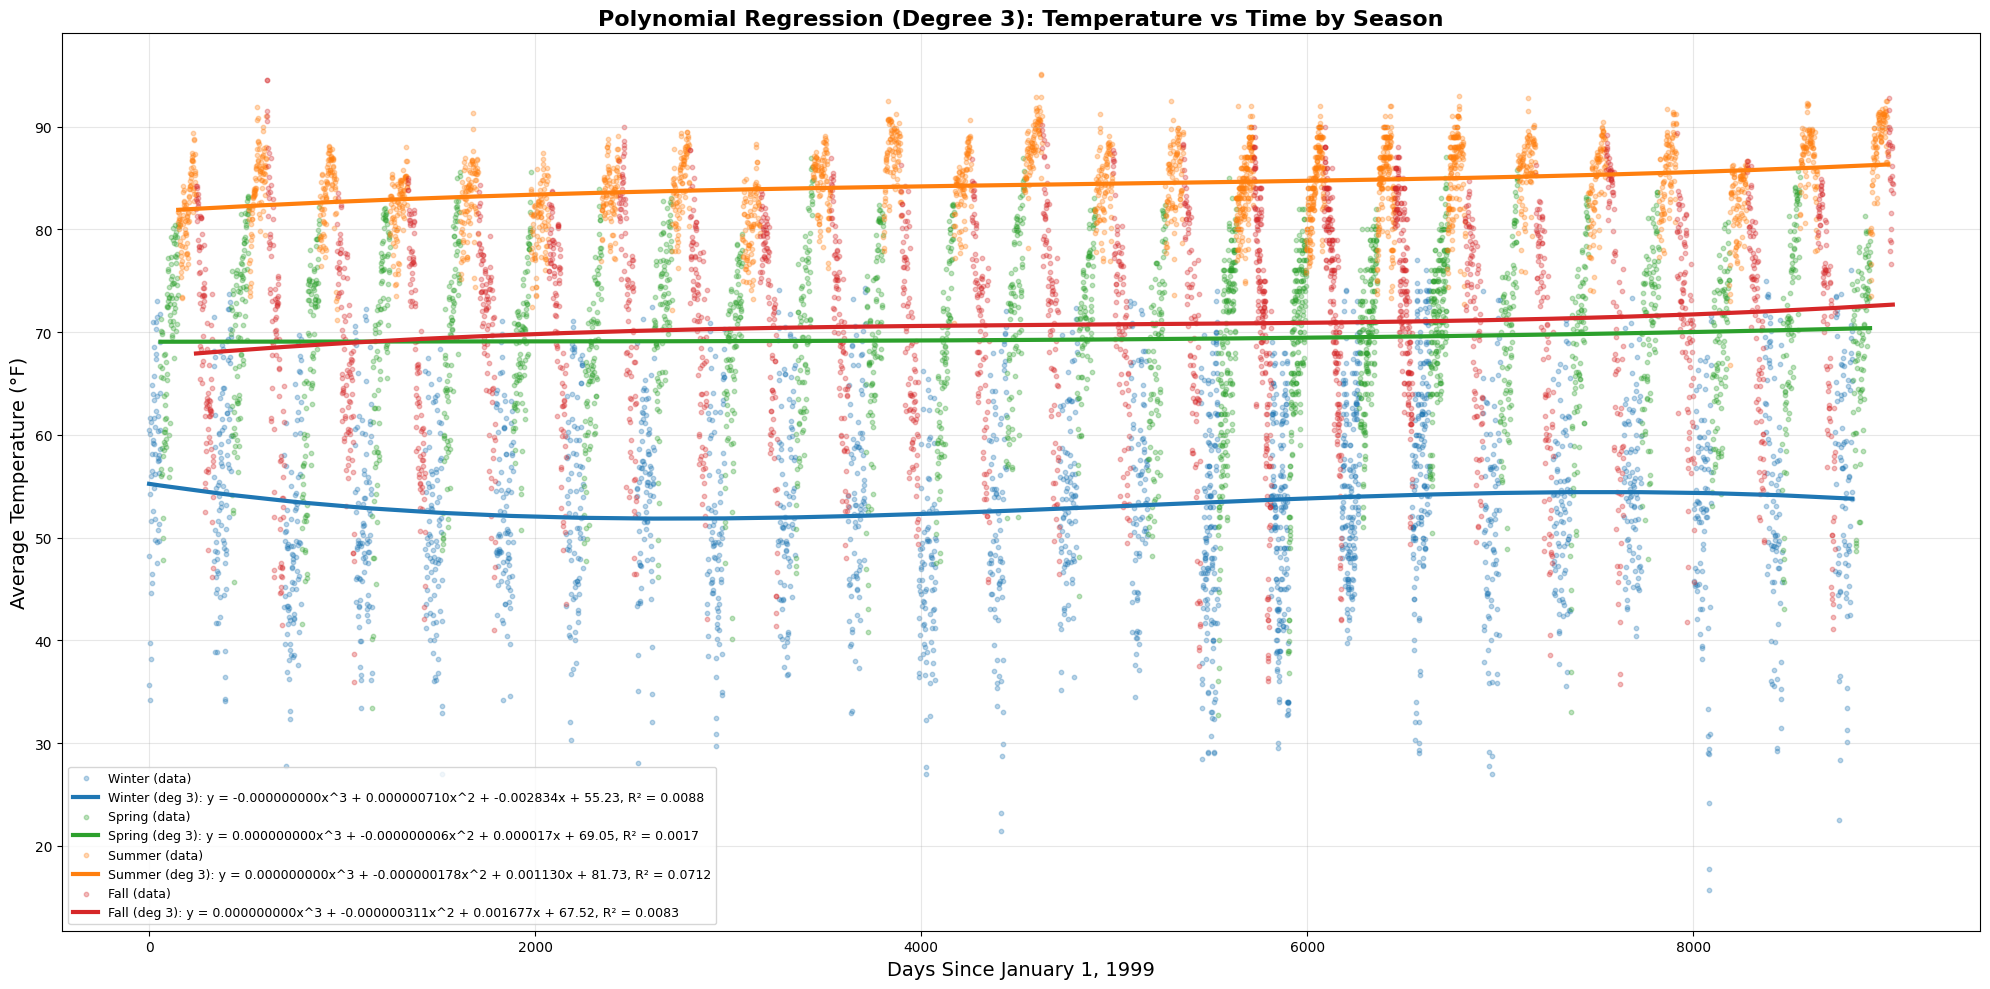


POLYNOMIAL MODEL COMPARISON: DEGREES 2 THROUGH 3


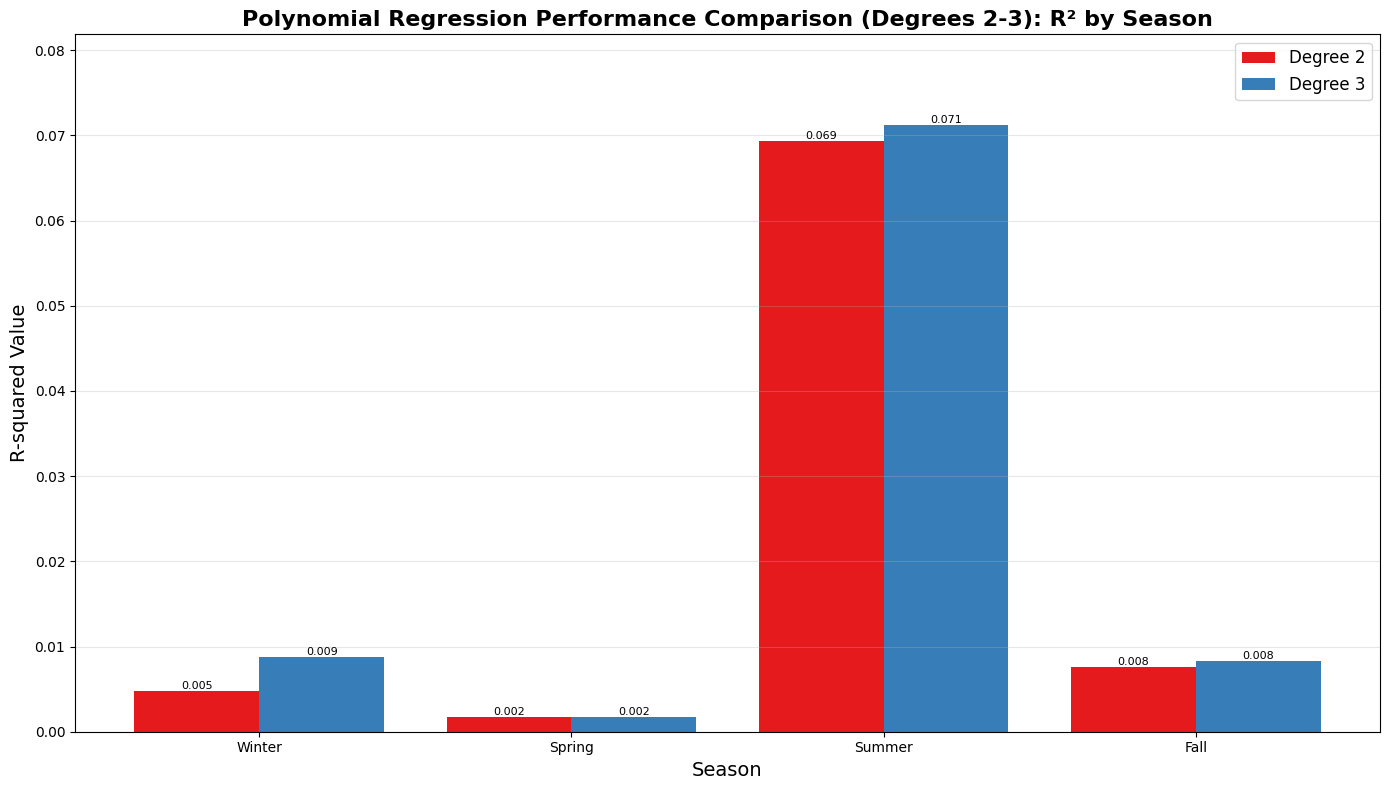


COMPLETE MODEL COMPARISON: LINEAR, LOG, AND POLYNOMIAL (Degrees 2-3)


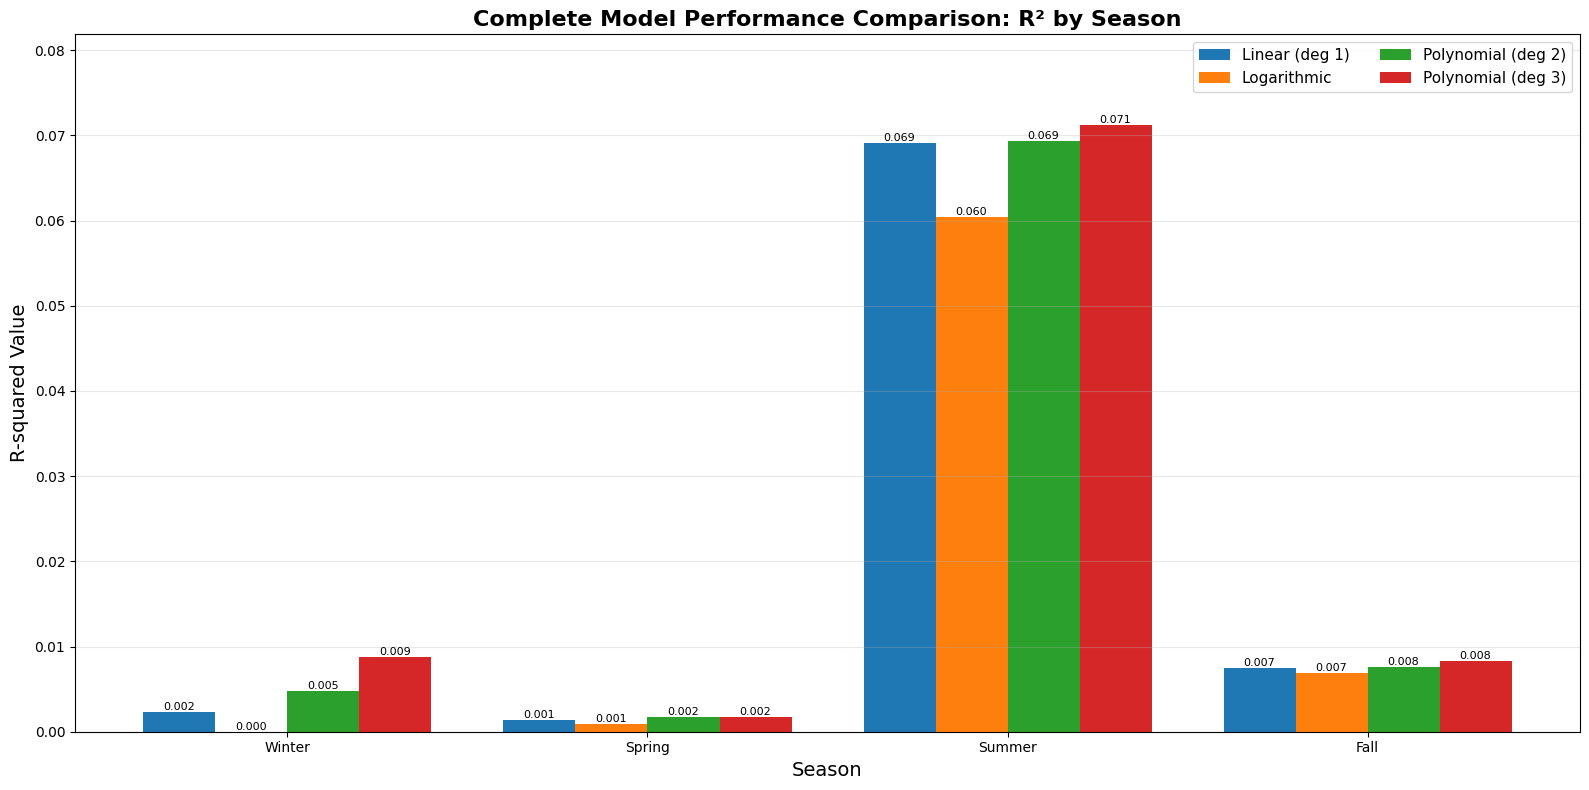


R-SQUARED VALUES TABLE

 Season Linear (deg 1) R² Log R² Poly2 R² Poly3 R²
Winter            0.0023 0.0000   0.0048   0.0088
Spring            0.0014 0.0009   0.0017   0.0017
Summer            0.0691 0.0604   0.0693   0.0712
  Fall            0.0075 0.0069   0.0076   0.0083

BEST MODEL BY SEASON
Winter: Polynomial (deg 3) (R² = 0.0088)
Spring: Polynomial (deg 3) (R² = 0.0017)
Summer: Polynomial (deg 3) (R² = 0.0712)
Fall: Polynomial (deg 3) (R² = 0.0083)



In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ============================================================================
# CONFIGURATION: Set the maximum polynomial degree here
# ============================================================================
degree = 3  # Change this to create polynomial regressions up to this degree
            # Note: degree 1 = linear regression (already computed)
            # Polynomial format applies to degrees >= 2

# ============================================================================
# POLYNOMIAL REGRESSION BY SEASON (Degrees 2 through 'degree')
# ============================================================================

# Ensure we have the necessary columns
data_clean = data.dropna(subset=['TempAvgF', 'DaysSince1999'])

# Define colors for each season
season_colors = {
    'Winter': '#1f77b4',  # Blue
    'Spring': '#2ca02c',  # Green
    'Summer': '#ff7f0e',  # Orange
    'Fall': '#d62728'     # Red
}

# Store results for polynomial degrees >= 2
poly_results = {d: {} for d in range(2, degree + 1)}

# Loop through each polynomial degree (starting from 2)
for current_degree in range(2, degree + 1):
    print("="*80)
    print(f"POLYNOMIAL REGRESSION (DEGREE {current_degree}) BY SEASON")
    print("="*80)

    plt.figure(figsize=(20, 10))

    for season in ['Winter', 'Spring', 'Summer', 'Fall']:
        season_data = data_clean[data_clean['Season'] == season]

        X = season_data['DaysSince1999'].values.reshape(-1, 1)
        y = season_data['TempAvgF'].values

        # Create polynomial features
        poly = PolynomialFeatures(degree=current_degree)
        X_poly = poly.fit_transform(X)

        # Fit model
        model = LinearRegression()
        model.fit(X_poly, y)

        # Predictions
        y_pred = model.predict(X_poly)
        r_squared = r2_score(y, y_pred)

        # Get coefficients
        coef = model.coef_
        intercept = model.intercept_

        # Store results
        poly_results[current_degree][season] = {
            'coefficients': coef,
            'intercept': intercept,
            'r_squared': r_squared
        }

        # Sort for plotting smooth curve
        sort_idx = np.argsort(X.flatten())
        X_sorted = X[sort_idx]
        y_pred_sorted = y_pred[sort_idx]

        # Build equation string
        equation_parts = []
        for i in range(len(coef) - 1, 0, -1):
            if i == 1:
                equation_parts.append(f"{coef[i]:.6f}x")
            else:
                equation_parts.append(f"{coef[i]:.9f}x^{i}")
        equation_parts.append(f"{intercept:.2f}")
        equation_str = " + ".join(equation_parts)

        # Plot
        plt.scatter(X, y, alpha=0.3, s=10, color=season_colors[season],
                   label=f'{season} (data)')

        if current_degree <= 3:
            # Show full equation for lower degrees
            plt.plot(X_sorted, y_pred_sorted, linewidth=3, color=season_colors[season],
                    label=f'{season} (deg {current_degree}): y = {equation_str}, R² = {r_squared:.4f}')
        else:
            # Just show R² for higher degrees (equation too long)
            plt.plot(X_sorted, y_pred_sorted, linewidth=3, color=season_colors[season],
                    label=f'{season} (deg {current_degree}): R² = {r_squared:.4f}')

        # Print results
        print(f"\n{season}:")
        print(f"  Equation: TempAvgF = {equation_str}")
        print(f"  R-squared: {r_squared:.4f}")

    plt.xlabel('Days Since January 1, 1999', fontsize=14)
    plt.ylabel('Average Temperature (°F)', fontsize=14)
    plt.title(f'Polynomial Regression (Degree {current_degree}): Temperature vs Time by Season',
             fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'polynomial_degree{current_degree}_regression_by_season.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# COMPARISON: ALL POLYNOMIAL MODELS (Degrees 2+)
# ============================================================================
if degree >= 2:
    print("\n" + "="*80)
    print(f"POLYNOMIAL MODEL COMPARISON: DEGREES 2 THROUGH {degree}")
    print("="*80)

    seasons = ['Winter', 'Spring', 'Summer', 'Fall']

    # Create comparison bar chart
    num_poly_models = degree - 1  # degrees 2 through 'degree'
    fig, ax = plt.subplots(figsize=(max(14, 10 + num_poly_models), 8))

    x_pos = np.arange(len(seasons))
    width = 0.8 / num_poly_models  # Adjust bar width based on number of models

    # Define distinct colors for each degree using a better color palette
    distinct_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
                       '#ffff33', '#a65628', '#f781bf', '#999999', '#66c2a5']

    # Plot bars for each degree (starting from 2)
    for idx, d in enumerate(range(2, degree + 1)):
        r2_values = [poly_results[d][s]['r_squared'] for s in seasons]
        offset = (idx - (num_poly_models - 1) / 2) * width
        bars = ax.bar(x_pos + offset, r2_values, width,
                      label=f'Degree {d}', color=distinct_colors[idx % len(distinct_colors)])

        # Add value labels on top of bars
        for i, (bar, val) in enumerate(zip(bars, r2_values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}',
                   ha='center', va='bottom', fontsize=8, rotation=0)

    ax.set_xlabel('Season', fontsize=14)
    ax.set_ylabel('R-squared Value', fontsize=14)
    ax.set_title(f'Polynomial Regression Performance Comparison (Degrees 2-{degree}): R² by Season',
                fontsize=16, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(seasons)
    ax.legend(fontsize=12, loc='best')
    ax.grid(True, alpha=0.3, axis='y')

    # Set y-axis limit with some headroom for labels
    all_r2 = []
    for d in range(2, degree + 1):
        all_r2.extend([poly_results[d][s]['r_squared'] for s in seasons])
    ax.set_ylim([0, max(all_r2) * 1.15])

    plt.tight_layout()
    plt.savefig(f'polynomial_comparison_degrees2to{degree}_r_squared.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================================================
# COMPARISON WITH LINEAR AND LOGARITHMIC
# ============================================================================
print("\n" + "="*80)
print(f"COMPLETE MODEL COMPARISON: LINEAR, LOG, AND POLYNOMIAL (Degrees 2-{degree})")
print("="*80)

seasons = ['Winter', 'Spring', 'Summer', 'Fall']
num_poly_models = max(0, degree - 1)  # degrees 2 through 'degree'
num_all_models = num_poly_models + 2  # polynomial degrees + linear + log

fig, ax = plt.subplots(figsize=(max(16, 12 + num_poly_models), 8))

x_pos = np.arange(len(seasons))
width = 0.8 / num_all_models

# Define distinct colors - using a handpicked palette for better distinction
distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
                   '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
                   '#aec7e8', '#ffbb78']

# Linear (degree 1)
linear_r2 = [linear_results[s]['r_squared'] for s in seasons]
bars_linear = ax.bar(x_pos - ((num_all_models - 1) / 2) * width, linear_r2, width,
                     label='Linear (deg 1)', color=distinct_colors[0])

# Add labels on bars
for bar, val in zip(bars_linear, linear_r2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{val:.3f}',
           ha='center', va='bottom', fontsize=8, rotation=0)

# Logarithmic
log_r2 = [log_results[s]['r_squared'] for s in seasons]
bars_log = ax.bar(x_pos - ((num_all_models - 3) / 2) * width, log_r2, width,
                  label='Logarithmic', color=distinct_colors[1])

# Add labels on bars
for bar, val in zip(bars_log, log_r2):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{val:.3f}',
           ha='center', va='bottom', fontsize=8, rotation=0)

# Polynomial degrees (2 and above)
for idx, d in enumerate(range(2, degree + 1)):
    r2_values = [poly_results[d][s]['r_squared'] for s in seasons]
    offset = ((idx - (num_all_models - 1) / 2) + 2) * width
    bars_poly = ax.bar(x_pos + offset, r2_values, width,
                       label=f'Polynomial (deg {d})', color=distinct_colors[(idx + 2) % len(distinct_colors)])

    # Add labels on bars
    for bar, val in zip(bars_poly, r2_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}',
               ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_xlabel('Season', fontsize=14)
ax.set_ylabel('R-squared Value', fontsize=14)
ax.set_title(f'Complete Model Performance Comparison: R² by Season',
            fontsize=16, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(seasons)
ax.legend(fontsize=11, loc='best', ncol=2)
ax.grid(True, alpha=0.3, axis='y')

# Set y-axis limit with extra headroom for labels
all_r2_complete = linear_r2 + log_r2
for d in range(2, degree + 1):
    all_r2_complete.extend([poly_results[d][s]['r_squared'] for s in seasons])
ax.set_ylim([0, max(all_r2_complete) * 1.15])

plt.tight_layout()
plt.savefig(f'complete_model_comparison_with_poly_degrees2to{degree}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# COMPARISON TABLE
# ============================================================================
print("\n" + "="*80)
print("R-SQUARED VALUES TABLE")
print("="*80)

comparison_data = []
for season in seasons:
    row = {
        'Season': season,
        'Linear (deg 1) R²': f"{linear_results[season]['r_squared']:.4f}",
        'Log R²': f"{log_results[season]['r_squared']:.4f}"
    }
    for d in range(2, degree + 1):
        row[f'Poly{d} R²'] = f"{poly_results[d][season]['r_squared']:.4f}"
    comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# ============================================================================
# BEST MODEL BY SEASON
# ============================================================================
print("\n" + "="*80)
print("BEST MODEL BY SEASON")
print("="*80)

for season in seasons:
    r2_values = {
        'Linear (deg 1)': linear_results[season]['r_squared'],
        'Logarithmic': log_results[season]['r_squared']
    }
    for d in range(2, degree + 1):
        r2_values[f'Polynomial (deg {d})'] = poly_results[d][season]['r_squared']

    best_model = max(r2_values, key=r2_values.get)
    best_r2 = r2_values[best_model]
    print(f"{season}: {best_model} (R² = {best_r2:.4f})")

print("\n" + "="*80)